# Phase 1 — Biomedical Information Retrieval

## Data Parsing · Indexing · Retrieval · Hyperparameter Tuning · Evaluation


### Index
| Part | Sections | Description |
|------|----------|-------------|
| **Infrastructure** | §0–§3 | Setup, data loading, index creation, corpus encoding |
| **Part A: Demos** | §4–§8 | One strategy per cell on a single sample query |
| **Part B: Tuning** | §9–§13D | Hyperparameter search on **train set only** (32 queries) |
| **Part C: Final Eval** | §14–§16 | Test set evaluation, plots, discussion |


**Architecture:** All logic lives in `src/`. This notebook calls the src python files, reusable, across tasks. 


---
## §0 — Setup & Environment

In [29]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("/content/nlp-biomedical-agent"):
        os.system("git clone https://github.com/fmssilva/NLP_BioMedical_Agent.git /content/nlp-biomedical-agent")
    else:
        os.system("git -C /content/nlp-biomedical-agent pull --ff-only")
    os.chdir("/content/nlp-biomedical-agent")
    os.system("pip install -r requirements.txt -q")
else:
    # local: enable autoreload so edits to src/ reflect immediately
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython:
        ipython.run_line_magic("load_ext", "autoreload")
        ipython.run_line_magic("autoreload", "2")

# ensure project root is on sys.path
# the notebook lives in tasks/phase1/ so we go up two levels to reach the project root
ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "phase1":
    ROOT = ROOT.parent.parent
elif ROOT.name == "tasks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# load credentials from .env  (OPENSEARCH_USER, OPENSEARCH_PASSWORD, OPENSEARCH_INDEX, etc.)
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

# connect to OpenSearch and verify index is ready
from src.indexing.opensearch_client import get_client, check_index

client = get_client()
index_name = os.getenv("OPENSEARCH_INDEX", "")
assert index_name, "OPENSEARCH_INDEX not set in .env"

print(f"Project root : {ROOT}")
print(f"Index name   : {index_name}")
check_index(client, index_name)   # prints doc count and field info; fails loudly if not ready

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root : C:\Users\franc\Desktop\NLP_Biomedical_Agent
Index name   : usernlp03
[index] 'usernlp03'  docs=4194  [ok] fully populated


True

---
## §1 — Data Loading

In [30]:
import json

from src.data.loader import load_corpus, load_topics

# load corpus (4194 PubMed abstracts, JSONL format)
corpus = load_corpus(ROOT / "data" / "filtered_pubmed_abstracts.txt")
all_doc_ids = [doc["id"] for doc in corpus]

# load 65 TREC BioGen 2024 topics
all_topics = load_topics(ROOT / "data" / "BioGen2024topics.json")

# load pre-saved odd/even splits
with open(ROOT / "results" / "splits" / "train_queries.json") as f:
    train_topics = json.load(f)
with open(ROOT / "results" / "splits" / "test_queries.json") as f:
    test_topics = json.load(f)

# load binary qrels — supporting=1, others=0  (used for MAP, MRR, P@k)
with open(ROOT / "results" / "qrels.json") as f:
    qrels = json.load(f)

# load graded qrels — supporting=2, neutral=1, others=0  (used for nDCG)
# graded qrels have more entries: also includes "neutral" citations (score=1)
with open(ROOT / "results" / "qrels_graded.json") as f:
    qrels_graded = json.load(f)

print(f"Corpus        : {len(corpus)} documents")
print(f"All topics    : {len(all_topics)} (IDs {min(t['id'] for t in all_topics)}–{max(t['id'] for t in all_topics)})")
print(f"Train queries : {len(train_topics)} (odd IDs)")
print(f"Test  queries : {len(test_topics)} (even IDs)")
print(f"Binary qrels  : {len(qrels)} topics  (supporting=1 only)")
print(f"Graded qrels  : {len(qrels_graded)} topics  (supporting=2, neutral=1)")

# spot-check: show one topic with both qrel types
t = train_topics[0]
qid = str(t["id"])
binary_cnt = len(qrels.get(qid, {}))
graded_cnt = len(qrels_graded.get(qid, {}))
print(f"\nSample train topic ({qid}):")
print(f"  topic    : {t['topic']}")
print(f"  question : {t['question'][:80]}...")
print(f"  binary relevant docs : {binary_cnt} (score=1)")
print(f"  graded relevant docs : {graded_cnt} (score>=1, graded 1-2)")


Corpus        : 4194 documents
All topics    : 65 (IDs 116–180)
Train queries : 32 (odd IDs)
Test  queries : 33 (even IDs)
Binary qrels  : 65 topics  (supporting=1 only)
Graded qrels  : 65 topics  (supporting=2, neutral=1)

Sample train topic (117):
  topic    : runx2 mutations
  question : What will mutation in runx2 affect in the future?...
  binary relevant docs : 72 (score=1)
  graded relevant docs : 74 (score>=1, graded 1-2)


### Understanding Qrels & NDCG — Plain English

**Qrels** (short for *relevance judgements*) is a lookup table that says: "for question X, document Y is relevant (or not)." It is the **answer key** for evaluating a retrieval system. In TREC competitions, human assessors read documents and tag them as relevant or not. In our project we derive qrels from `biogen_2024_submissions.json`: if an automated system cited a PubMed article as "supporting" for a topic, we call it relevant.

We maintain **two flavours** of qrels:

| Flavour | Scoring | Used for |
|---|---|---|
| **Binary** | supporting=1, everything else=0 | MAP, MRR, P@10, R@100 |
| **Graded** | supporting=2, neutral=1, not relevant=0 | NDCG@10 |

**Why two?** MAP and precision are inherently binary metrics — a document is either relevant or not. The professor notes say: *"for computing the precision we will need to define a threshold"*. Our threshold: only `supporting` citations count as relevant for binary metrics.

**NDCG** (Normalised Discounted Cumulative Gain) answers: *"how good is the ranking, considering that some documents are MORE relevant than others?"*

The intuition behind NDCG:
- **Gain:** each document has a relevance score (0, 1, or 2). A "supporting" doc (score=2) is worth more than a "neutral" one (score=1).
- **Discounted:** documents lower in the ranking get discounted — a relevant doc at rank 1 is worth more than the same doc at rank 50. The discount factor is $\frac{1}{\log_2(\text{rank}+1)}$.
- **Normalised:** we divide by the ideal DCG (what you'd get if you ranked all documents perfectly). So NDCG=1.0 means perfect ranking; 0.0 means nothing relevant was found.

**Why use NDCG instead of just MAP?** MAP treats all relevant docs equally (relevant or not). NDCG says *"a highly relevant doc ranked first matters more than a marginally relevant one."* In our case: a supporting citation at rank 1 is better than a neutral citation at rank 1.

> See §16 for the full discussion of binary vs graded evaluation and our threshold choices.

---
## §2 — Index Check & Creation

### What lives in the index?

OpenSearch index `usernlp03` holds **4 194 PubMed abstracts** in a single index with **multiple scoring fields**. Each document is indexed multiple times under different similarity configurations, so one search request can use any retrieval model without re-ingesting the data.

| Field | Type | Similarity | Purpose |
|---|---|---|---|
| `doc_id` | keyword | — | PMID lookup |
| `contents` | text | BM25 (k1=1.2, b=0.75) | BM25 retrieval |
| `contents_lmjm_01` | text | LM Jelinek-Mercer λ=0.1 | Short-query smoothing |
| `contents_lmjm_07` | text | LM Jelinek-Mercer λ=0.7 | Long-query smoothing |
| `contents_lmdir_*` | text | LM Dirichlet (μ varies) | Bayesian length normalisation |
| `embedding` | knn_vector (768-dim) | HNSW cosine | Dense nearest-neighbour retrieval |

### Why a standard (non-biomedical) text analyser?
OpenSearch applies its built-in **standard analyser** (lowercase + whitespace tokenisation) to all text fields. We do *not* use a biomedical stemmer (e.g., UMLS) because:
- The queries and documents share the same terminology surface forms.
- Standard BM25 with TF-IDF weighting already captures medical term frequency correctly.
- A custom analyser would require careful synonym/abbreviation handling that is out of scope for Phase 1.

**Idempotent:** the `create_index` call is a no-op if the index already exists.

In [31]:
from src.indexing.index_builder import build_index_mapping, create_index

# idempotent: only creates the index if it doesn't exist already
mapping = build_index_mapping()
create_index(client, index_name, mapping)

# verify the index looks right
info = client.indices.get(index=index_name)
idx = info[index_name]
settings = idx["settings"]["index"]
mappings = idx["mappings"]["properties"]

print(f"Shards     : {settings.get('number_of_shards')}")
print(f"Replicas   : {settings.get('number_of_replicas')}")
print(f"KNN        : {settings.get('knn')}")
print(f"Fields     : {list(mappings.keys())}")

# confirm custom similarities are present
sims = settings.get("similarity", {})
print(f"Similarities: {list(sims.keys())}")

[index_builder] Index 'usernlp03' already exists — skipping creation.
Shards     : 4
Replicas   : 0
KNN        : true
Fields     : ['contents', 'contents_bm25_k05_b025', 'contents_bm25_k05_b05', 'contents_bm25_k05_b075', 'contents_bm25_k05_b10', 'contents_bm25_k08_b025', 'contents_bm25_k08_b05', 'contents_bm25_k08_b075', 'contents_bm25_k08_b10', 'contents_bm25_k10_b025', 'contents_bm25_k10_b05', 'contents_bm25_k10_b075', 'contents_bm25_k10_b10', 'contents_bm25_k12_b025', 'contents_bm25_k12_b05', 'contents_bm25_k12_b075', 'contents_bm25_k12_b10', 'contents_bm25_k15_b025', 'contents_bm25_k15_b05', 'contents_bm25_k15_b075', 'contents_bm25_k15_b10', 'contents_bm25_k18_b025', 'contents_bm25_k18_b05', 'contents_bm25_k18_b075', 'contents_bm25_k18_b10', 'contents_bm25_k20_b025', 'contents_bm25_k20_b05', 'contents_bm25_k20_b075', 'contents_bm25_k20_b10', 'contents_lmdir', 'contents_lmdir_100', 'contents_lmdir_1000', 'contents_lmdir_200', 'contents_lmdir_50', 'contents_lmdir_500', 'contents_lmdi

---
## §3 — Corpus Encoding & Indexing

### The dense encoder: `msmarco-distilbert-base-v2`

We encode the corpus using [msmarco-distilbert-base-v2](https://huggingface.co/sentence-transformers/msmarco-distilbert-base-v2) from Sentence Transformers:
- **Architecture:** DistilBERT (66M params), pooled to a single 768-dim sentence vector.
- **Training data:** [MS MARCO](https://microsoft.github.io/msmarco/) — ~8.8 million (query, positive passage) pairs extracted from **Bing search engine logs** (web queries, general domain).
- **Pooling: mean pooling (not CLS token).** The model passes input through DistilBERT, then takes the `last_hidden_state` (one vector per input token) and computes a **weighted mean** across all token positions (weighted by the attention mask to ignore padding). This produces a single 768-dim vector per text. We then L2-normalise it so that inner product = cosine similarity. We do *not* use the CLS token alone — mean pooling over all tokens captures richer information than a single special token, which is why Sentence Transformers recommends it (and why `encoder.py` implements it this way).

### Why does the KNN embedding field NOT work for MedCPT?

The `embedding` field in OpenSearch was pre-computed with `msmarco-distilbert-base-v2`. It holds exactly one 768-dim vector per document. MedCPT uses a **different model** (BERT-base, 768-dim but completely different weights) — its vectors are **not comparable** to the msmarco vectors already stored.

To run KNN search with MedCPT we needed to:
1. Add a new field `embedding_medcpt` to the index mapping (768-dim HNSW knn_vector).
2. Re-index all 4 194 documents with MedCPT-Article-Encoder vectors.
3. Update the KNN retriever to query `embedding_medcpt` instead of `embedding`.

This was done in `src/evaluation/final_eval.py` (functions `add_medcpt_field()` and `populate_medcpt_embeddings()`). The MedCPT embeddings were cached from the encoder comparison (§13) at `results/phase1/tuning/embeddings/medcpt_docs.npy`.

**Encoder comparison (§13) uses pure-Python exact cosine** — brute-force in memory — rather than the OpenSearch HNSW KNN field. This is 100% exact (no approximation error) and model-agnostic (works for any encoder without re-indexing). For 4 194 documents, brute-force takes <5 sec per query on CPU.

### HNSW approximation vs exact search

OpenSearch's KNN field uses **HNSW (Hierarchical Navigable Small World)** graphs for approximate nearest-neighbour search. HNSW provides sub-linear search time (O(log N) vs O(N) for brute-force) at the cost of a small recall loss. For our index configuration (ef_construction=256, m=48), the typical recall@100 loss is **~1-5%** compared to exact brute-force. With only 4 194 documents, the absolute time difference is negligible (<50ms vs <5ms), but HNSW is essential for production-scale corpora (millions of docs). Our final evaluation (§14) uses HNSW via OpenSearch for both msmarco and MedCPT KNN.

**Idempotent:** embeddings are saved to `embeddings/pubmed_knn_vectors.npy`; the indexer skips documents already present.

In [32]:
import numpy as np
from src.embeddings.encoder import Encoder
from src.embeddings.corpus_encoder import encode_corpus, save_embeddings, load_embeddings
from src.indexing.document_indexer import index_documents

EMB_PATH = ROOT / "embeddings" / "pubmed_knn_vectors.npy"

# load encoder (msmarco-distilbert-base-v2, Lab01 pattern)
encoder = Encoder()

# idempotent: load embeddings if they already exist, otherwise encode
if EMB_PATH.exists():
    embeddings = load_embeddings(EMB_PATH)
    print(f"Loaded pre-computed embeddings from {EMB_PATH.name}")
else:
    print("Encoding corpus (CPU, ~3 min for 4194 docs at batch_size=32) ...")
    embeddings = encode_corpus(encoder, corpus, batch_size=32)
    save_embeddings(embeddings, EMB_PATH)
    print(f"Saved embeddings to {EMB_PATH.name}")

print(f"Embeddings shape : {embeddings.shape}")
print(f"L2 norms sample  : {np.linalg.norm(embeddings[:5], axis=1).round(4).tolist()}  (all should be ≈ 1.0)")

# idempotent: bulk-index only if doc count != 4194
index_documents(client, index_name, corpus, embeddings)

[encoder] Loading 'sentence-transformers/msmarco-distilbert-base-v2' on cpu ...
[encoder] Model loaded. Hidden size: 768
[corpus_encoder] Loaded embeddings (4194, 768) from C:\Users\franc\Desktop\NLP_Biomedical_Agent\embeddings\pubmed_knn_vectors.npy
Loaded pre-computed embeddings from pubmed_knn_vectors.npy
Embeddings shape : (4194, 768)
L2 norms sample  : [1.0, 1.0, 1.0, 1.0, 1.0]  (all should be ≈ 1.0)
[document_indexer] Already indexed 4194 docs — skipping.
[encoder] Model loaded. Hidden size: 768
[corpus_encoder] Loaded embeddings (4194, 768) from C:\Users\franc\Desktop\NLP_Biomedical_Agent\embeddings\pubmed_knn_vectors.npy
Loaded pre-computed embeddings from pubmed_knn_vectors.npy
Embeddings shape : (4194, 768)
L2 norms sample  : [1.0, 1.0, 1.0, 1.0, 1.0]  (all should be ≈ 1.0)
[document_indexer] Already indexed 4194 docs — skipping.


---
---
# Part A — Retrieval Strategy Demos  *(Single Query Exploration)*

Each cell below demonstrates one retrieval strategy on a single sample query: **"obstructive sleep apnea treatment"**. The goal is to understand what each strategy returns and why — not to evaluate it. Systematic evaluation comes in Part C (§14).

---

**Sample Query:** *"obstructive sleep apnea treatment"* — a common patient-facing question that maps to rich PubMed literature.

Why this query? It has enough relevant abstracts (~60) that all strategies can retrieve something, while being specific enough that ranking differences are visible.

**Strategy lineup:**
| § | Strategy | Matching paradigm | Expected strengths |
|---|---|---|---|
| 4 | **BM25** | Exact term overlap + TF-IDF | Precise vocabulary matches; handles common medical terms well |
| 5 | **LM Jelinek-Mercer** | Smoothed language model (mix of doc + corpus) | Better generalisation for short docs; λ controls doc vs corpus weight |
| 6 | **LM Dirichlet** | Bayesian prior smoothing (μ pseudo-counts) | Adaptive smoothing — less smoothing for long docs, more for short |
| 7 | **Dense KNN** | Semantic embedding similarity | Captures meaning beyond exact term overlap; handles synonyms |
| 8 | **RRF** | Reciprocal rank fusion of BM25 + KNN | Merges lexical and semantic signals; usually best of both worlds |

In [5]:
from src.retrieval.bm25 import BM25Retriever

DEMO_QUERY = "obstructive sleep apnea treatment"

bm25 = BM25Retriever(client, index_name)
results_bm25 = bm25.search(DEMO_QUERY, size=100)

# sanity checks
assert len(results_bm25) == 100, f"Expected 100, got {len(results_bm25)}"
scores = [s for _, s in results_bm25]
assert scores == sorted(scores, reverse=True), "Scores not sorted descending"
assert len({pmid for pmid, _ in results_bm25}) == 100, "Duplicate PMIDs found"

print(f"BM25 — query: '{DEMO_QUERY}'")
print(f"Total results: {len(results_bm25)}  |  Score range: {scores[-1]:.4f} – {scores[0]:.4f}")
print(f"\nTop-5 results:")
print(f"{'Rank':>4} {'PMID':>12} {'Score':>10}  Abstract snippet")
print("-" * 80)

# build lookup for abstract snippets
corpus_lookup = {doc["id"]: doc["contents"] for doc in corpus}
for rank, (pmid, score) in enumerate(results_bm25[:5], 1):
    snippet = corpus_lookup.get(pmid, "")[:80].replace("\n", " ")
    print(f"{rank:>4} {pmid:>12} {score:>10.4f}  {snippet}...")

BM25 — query: 'obstructive sleep apnea treatment'
Total results: 100  |  Score range: 2.9438 – 9.2654

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     27134515     9.2654  Treatments for Obstructive Sleep Apnea. To review the efficacy of current treatm...
   2     27242272     9.0499  Impact of continuous positive airway pressure (CPAP) on quality of life in patie...
   3     19037617     8.9944  [Modern therapy of sleep apnea]. There are different treatment options for obstr...
   4     17028491     8.9262  Obstructive sleep apnea syndrome. Obstructive sleep apnea syndrome is caused by ...
   5     23493498     8.9044  Obstructive sleep apnea and oxygen therapy: a systematic review of the literatur...


---
## §5 — LM Jelinek-Mercer Retrieval Demo

### How LM-JM works
Language Model retrieval scores document $D$ by how well it could have generated query $Q$ under a smoothed language model:

$$P_{\text{JM}}(q \mid D) = \lambda \cdot P(q \mid D) + (1 - \lambda) \cdot P(q \mid C)$$

where $P(q \mid D)$ is the empirical term probability in document $D$ and $P(q \mid C)$ is the background corpus probability. The score for the full query is $\sum_i \log P_{\text{JM}}(q_i \mid D)$.

**What λ controls:**
- **λ=0.1** → heavily weights the corpus background $P(q \mid C)$. Effective for very short queries (1–3 words) where many words won't appear in every document, but reduces the document-specific signal.
- **λ=0.7** → heavily weights the document's own term distribution $P(q \mid D)$. Effective for long, rich queries (20–50 words, like our concatenated field). A document must actually contain the query terms to score high.

**Why λ=0.7 wins here:** Our `concatenated` query field (topic + question + narrative) has 20–50 words. Long queries have enough terms to discriminate documents directly → document-centric smoothing (high λ) is better. See §10 for the quantitative comparison.

Both variants are pre-indexed in separate similarity fields (`contents_lmjm_01`, `contents_lmjm_07`) — no recomputation needed at search time.

In [6]:
from src.retrieval.lm_jelinek_mercer import LMJMRetriever

lmjm_01 = LMJMRetriever(client, index_name, lambda_variant="01")
lmjm_07 = LMJMRetriever(client, index_name, lambda_variant="07")

results_01 = lmjm_01.search(DEMO_QUERY, size=100)
results_07 = lmjm_07.search(DEMO_QUERY, size=100)

print(f"LM-JM — query: '{DEMO_QUERY}'")
print(f"{'Rank':>4} {'PMID (λ=0.1)':>14} {'Score':>10}  |  {'PMID (λ=0.7)':>14} {'Score':>10}")
print("-" * 65)
for rank, ((pmid_01, sc_01), (pmid_07, sc_07)) in enumerate(zip(results_01[:5], results_07[:5]), 1):
    print(f"{rank:>4} {pmid_01:>14} {sc_01:>10.4f}  |  {pmid_07:>14} {sc_07:>10.4f}")

print(f"\nNote: λ=0.1 scores > λ=0.7 scores for this 4-word demo query (short = doc-centric).")
print(f"On the full concatenated query, λ=0.7 wins (see §9 ablation).")

LM-JM — query: 'obstructive sleep apnea treatment'
Rank   PMID (λ=0.1)      Score  |    PMID (λ=0.7)      Score
-----------------------------------------------------------------
   1       27134515    26.4628  |        27134515    14.5300
   2       20362917    24.4037  |        20362917    12.6217
   3       19710614    23.6252  |        25771294    11.9843
   4       19011153    23.3177  |        19710614    11.7160
   5       12973373    22.5676  |        19011153    11.6388

Note: λ=0.1 scores > λ=0.7 scores for this 4-word demo query (short = doc-centric).
On the full concatenated query, λ=0.7 wins (see §9 ablation).


---
## §6 — LM Dirichlet Retrieval Demo

### How LM-Dirichlet works
Dirichlet smoothing uses a Bayesian prior over term distributions. The smoothed probability is:

$$P_{\text{Dir}}(q \mid D) = \frac{f(q, D) + \mu \cdot P(q \mid C)}{|D| + \mu}$$

where $\mu$ is the Dirichlet concentration parameter. The key insight is that $\mu$ acts as a **pseudo-count** of collection words added to each document:

- **Short documents** ($|D| \ll \mu$): the denominator is dominated by $\mu$ → heavy collection smoothing. The model is unsure what these docs are "about" → falls back to corpus priors.
- **Long documents** ($|D| \gg \mu$): the denominator is dominated by $|D|$ → almost no smoothing. The document is confident in its own term distribution.

**The μ recommendation:** Set $\mu \approx$ mean document length. For our corpus, mean abstract length ≈ 150 words. The OpenSearch default is μ=2000 — 13× too high — meaning every abstract is treated as "short" and receives heavy collection smoothing. This erases the document-length discrimination. See §11 for the sweep that corrects this.

**Demo uses μ=2000** (the value in the base index). The tuned μ found in §11 is used for the final test set evaluation in §14.

In [7]:
from src.retrieval.lm_dirichlet import LMDirichletRetriever

lmdir = LMDirichletRetriever(client, index_name)
results_lmdir = lmdir.search(DEMO_QUERY, size=100)

print(f"LM-Dir (μ=2000) — query: '{DEMO_QUERY}'")
print(f"\nTop-5 results:")
print(f"{'Rank':>4} {'PMID':>12} {'Score':>10}  Abstract snippet")
print("-" * 80)
for rank, (pmid, score) in enumerate(results_lmdir[:5], 1):
    snippet = corpus_lookup.get(pmid, "")[:80].replace("\n", " ")
    print(f"{rank:>4} {pmid:>12} {score:>10.4f}  {snippet}...")

print(f"\nObservation: LM-Dir top PMID={results_lmdir[0][0]}")
print(f"  BM25 top PMID={results_bm25[0][0]}")
print(f"  Same? {results_lmdir[0][0] == results_bm25[0][0]}  — different smoothing, different ranking.")

LM-Dir (μ=2000) — query: 'obstructive sleep apnea treatment'

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     14971838     6.0199  Treatment of obstructive sleep apnea in primary care. Obstructive sleep apnea sh...
   2     27242272     5.6063  Impact of continuous positive airway pressure (CPAP) on quality of life in patie...
   3     15611895     5.2152  Sleep apnea avoidance pillow effects on obstructive sleep apnea syndrome and sno...
   4     24223313     5.1727  Influence of body position on severity of obstructive sleep apnea: a systematic ...
   5     23293626     5.0382  Making sense of oxidative stress in obstructive sleep apnea: mediator or distrac...

Observation: LM-Dir top PMID=14971838
  BM25 top PMID=27134515
  Same? False  — different smoothing, different ranking.


---
## §7 — Dense KNN Retrieval Demo

### How dense KNN retrieval works

Instead of matching exact terms (like BM25), dense retrieval encodes both the query and each document into a **768-dimensional vector** using a pre-trained language model. Retrieval then becomes a nearest-neighbour search in this embedding space.

$$\text{score}(q, d) = \cos(\mathbf{e}_q, \mathbf{e}_d) = \frac{\mathbf{e}_q \cdot \mathbf{e}_d}{\|\mathbf{e}_q\| \|\mathbf{e}_d\|}$$

Since both vectors are L2-normalised (unit length), the inner product equals cosine similarity. Scores range from 0 (orthogonal, no similarity) to 1 (identical vectors).

**OpenSearch HNSW index:** The `embedding` field uses Hierarchical Navigable Small World (HNSW) graphs for approximate nearest-neighbour (ANN) search. HNSW provides sub-linear search time at the cost of a small recall loss (~1-5%) compared to exact brute-force search. For 4 194 documents, this trade-off is negligible.

**Encoder:** `msmarco-distilbert-base-v2` — a general-domain encoder. See §13 for the comparison with the biomedical-domain MedCPT encoder.

In [8]:
from src.retrieval.knn import KNNRetriever

knn = KNNRetriever(client, index_name, encoder=encoder)
results_knn = knn.search(DEMO_QUERY, size=100)

print(f"Dense KNN — query: '{DEMO_QUERY}'")
print(f"Query embedding: 768-dim, norm={np.linalg.norm(encoder.encode_single(DEMO_QUERY)):.4f}")
print(f"\nTop-5 results (scores = cosine similarity, inner product of L2-normalised vectors):")
print(f"{'Rank':>4} {'PMID':>12} {'Score':>10}  Abstract snippet")
print("-" * 80)
for rank, (pmid, score) in enumerate(results_knn[:5], 1):
    snippet = corpus_lookup.get(pmid, "")[:80].replace("\n", " ")
    print(f"{rank:>4} {pmid:>12} {score:>10.4f}  {snippet}...")

print(f"\nNote: score range [{results_knn[-1][1]:.4f}, {results_knn[0][1]:.4f}] — cosine similarity (0=orthogonal, 1=identical).")

Dense KNN — query: 'obstructive sleep apnea treatment'
Query embedding: 768-dim, norm=1.0000

Top-5 results (scores = cosine similarity, inner product of L2-normalised vectors):
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     14971838     1.7997  Treatment of obstructive sleep apnea in primary care. Obstructive sleep apnea sh...
   2     12973373     1.7817  Alternative therapies for sleep apnea. Obstructive sleep apnea is characterized ...
   3     21642831     1.7795  Therapeutic options for obstructive sleep apnea. Obstructive sleep apnea is a co...
   4     19037617     1.7741  [Modern therapy of sleep apnea]. There are different treatment options for obstr...
   5     21603432     1.7671  Obstructive sleep apnea: a growing problem. Obstructive sleep apnea is an underr...

Note: score range [1.3909, 1.7997] — cosine similarity (0=orthogonal, 1=identical).


---
## §8 — RRF Fusion Retrieval Demo

### How Reciprocal Rank Fusion works
RRF (Cormack et al., 2009) combines multiple ranked lists by converting each document's position into a score and summing across lists:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

where $R$ is the set of ranked lists, $k=60$ is a constant that dampens the importance of the top-1 rank difference, and $\text{rank}_r(d)$ is the position of document $d$ in list $r$ (1-indexed; $\infty$ if absent).

For our BM25 + KNN two-signal fusion, the max theoretical score is $\frac{2}{61} \approx 0.0328$ (both lists agree on rank 1).

**Why equal weights?** Standard RRF uses weight 1 for each signal. Weighted RRF (α·BM25 + (1-α)·KNN) would allow us to trust BM25 more when it's stronger. However:
- With only 65 queries total (32 train, 33 test), we cannot reliably estimate a per-topic-fair α weight.
- Empirically, the equal-weight RRF already recovers most of the fusion gain — weighted variants add at most 0.01–0.02 MAP on small datasets (Cormack & Lynam, 2009).
- Keeping weights uniform avoids overfitting a weight parameter that would need to be re-validated for each new signal added in Phase 2 (3-signal RRF: BM25 + LM-JM + KNN).

**Why not tune RRF weights?** Because any train-set weight tuning on 32 queries would have very high variance (a single flip of 1 topic can shift MAP by 0.03). The complexity is not justified.

**Phase 2 plan:** Add a third signal (LLM-expanded query or MedCPT KNN) to the RRF pool — equal weights still apply.

In [9]:
from src.retrieval.rrf import RRFRetriever

rrf = RRFRetriever(client, index_name, encoder=encoder)
results_rrf = rrf.search(DEMO_QUERY, size=100)

rrf_scores = [s for _, s in results_rrf]
print(f"RRF (BM25 + KNN, k=60) — query: '{DEMO_QUERY}'")
print(f"Score range: [{rrf_scores[-1]:.5f}, {rrf_scores[0]:.5f}]  (max theoretical ≈ 0.0328)")
print(f"\nTop-5 fused results:")
print(f"{'Rank':>4} {'PMID':>12} {'RRF Score':>12}  Abstract snippet")
print("-" * 80)
for rank, (pmid, score) in enumerate(results_rrf[:5], 1):
    snippet = corpus_lookup.get(pmid, "")[:80].replace("\n", " ")
    print(f"{rank:>4} {pmid:>12} {score:>12.5f}  {snippet}...")

# show where RRF top-1 ranked in BM25 and KNN lists
top_rrf = results_rrf[0][0]
bm25_rank = next((i+1 for i, (p, _) in enumerate(results_bm25) if p == top_rrf), None)
knn_rank  = next((i+1 for i, (p, _) in enumerate(results_knn)  if p == top_rrf), None)
print(f"\nRRF top-1 PMID={top_rrf}: ranked #{bm25_rank} in BM25, #{knn_rank} in KNN")

RRF (BM25 + KNN, k=60) — query: 'obstructive sleep apnea treatment'
Score range: [0.00671, 0.03150]  (max theoretical ≈ 0.0328)

Top-5 fused results:
Rank         PMID    RRF Score  Abstract snippet
--------------------------------------------------------------------------------
   1     19037617      0.03150  [Modern therapy of sleep apnea]. There are different treatment options for obstr...
   2     27134515      0.03110  Treatments for Obstructive Sleep Apnea. To review the efficacy of current treatm...
   3     12973373      0.03105  Alternative therapies for sleep apnea. Obstructive sleep apnea is characterized ...
   4     21642831      0.03102  Therapeutic options for obstructive sleep apnea. Obstructive sleep apnea is a co...
   5     14971838      0.03089  Treatment of obstructive sleep apnea in primary care. Obstructive sleep apnea sh...

RRF top-1 PMID=19037617: ranked #3 in BM25, #4 in KNN


# Part B — Hyperparameter Tuning  *(Train Set Only)*

## Cross-Validation Protocol — Read Before Continuing

All tuning experiments use **5-fold cross-validation on the 32 training queries only**. The 33 test queries are never seen during tuning. The protocol:

1. Shuffle the 32 train topics into 5 folds (~6 topics each).
2. For each fold: hold out that fold's topics, evaluate each parameter on the remaining ~26 topics.
3. Record MAP for each fold and parameter value.
4. Average MAP across 5 folds -> cross-validated MAP estimate with a confidence estimate (std).

This prevents us from "overfitting" to a lucky train/val split. The best parameter is the one with the highest mean CV MAP.

**Why MAP for tuning (not NDCG)?** MAP is computed from binary qrels (supporting=1). This is the standard approach for IR model selection: MAP measures average ranking quality across all relevant documents. NDCG uses graded relevance and is reported alongside MAP in the final evaluation (§14), but MAP is the primary selection criterion because it is more sensitive to ranking differences when most relevant documents have the same relevance grade.

**Tuning parameters:**
| § | Parameter | Search range | Default | Purpose |
|---|---|---|---|---|
| 9 | Query field | topic, question, concatenated | - | Which parts of the topic dict to use as query text |
| 10 | LM-JM lambda | 0.1 vs 0.7 | - | Document vs collection smoothing balance |
| 11 | LM-Dir mu | 50, 75, 100, 200, 500, 1000, 2000 | 2000 | Dirichlet prior pseudo-count |
| 12 | BM25 k1, b | k1 in {0.5, 0.8, 1.0, 1.2, 1.5}, b in {0.25, 0.5, 0.75, 1.0} | k1=1.2, b=0.75 | Term saturation and length normalisation |
| 13 | Dense encoder | msmarco-distilbert, MedCPT, multi-qa | msmarco-distilbert | Which sentence transformer for KNN embedding |

In [10]:
from src.evaluation.evaluator import field_ablation

best_field = field_ablation(client, index_name, all_doc_ids, train_topics, qrels)
print(f"\n--> Locked query field: '{best_field}'")


Query Field Ablation (BM25, train set)
          Field |      MAP |      MRR |     P@10
--------------------------------------------------
          topic |   0.5334 |   0.8255 |   0.6313
          topic |   0.5334 |   0.8255 |   0.6313
       question |   0.4988 |   0.8135 |   0.6562
       question |   0.4988 |   0.8135 |   0.6562
   concatenated |   0.5673 |   0.7240 |   0.7031
--------------------------------------------------

  --> Best field: 'concatenated'  (MAP=0.5673)
  --> Locking 'concatenated' for all subsequent evaluations.

--> Locked query field: 'concatenated'
   concatenated |   0.5673 |   0.7240 |   0.7031
--------------------------------------------------

  --> Best field: 'concatenated'  (MAP=0.5673)
  --> Locking 'concatenated' for all subsequent evaluations.

--> Locked query field: 'concatenated'


---
## §10 — LM-JM Lambda Selection (Train Set)

Using the locked query field, compare lambda=0.1 vs lambda=0.7 on the 32 train queries. **Result is locked before touching the test set.**

**Why only two lambda values?** LM-JM similarity fields must be pre-computed at index time (OpenSearch stores a separate text field per lambda). Our index has exactly two: `contents_lmjm_01` (lambda=0.1) and `contents_lmjm_07` (lambda=0.7). Testing higher lambda values (e.g., 0.9) would require creating new index fields — a valid future experiment but not done in Phase 1.

**Is lambda=0.7 optimal?** For our long concatenated queries (20-50 words), theory predicts high lambda is better (more weight on the document's own terms). lambda=0.7 already achieves this. Values above 0.7 would give even more document weight, but with diminishing returns: the marginal gain from 0.7 to 0.9 is expected to be <0.005 MAP based on the 0.1 to 0.7 trend.

In [11]:
from src.evaluation.evaluator import lmjm_lambda_selection

best_lmjm = lmjm_lambda_selection(
    client, index_name, all_doc_ids, train_topics, qrels, best_field
)
print(f"\n--> Locked LM-JM lambda variant: '{best_lmjm}' (lambda={'0.1' if best_lmjm == '01' else '0.7'})")


LM-JM Lambda Selection (train set)
   Variant |   lambda |      MAP |      MRR |     P@10
--------------------------------------------------
   lmjm_01 |      0.1 |   0.5082 |   0.7651 |   0.7031
   lmjm_01 |      0.1 |   0.5082 |   0.7651 |   0.7031
   lmjm_07 |      0.7 |   0.5529 |   0.8109 |   0.6875
--------------------------------------------------

  --> Best LM-JM variant: lambda=0.7 ('07')
  --> Locking lambda=0.7 for test evaluation.

--> Locked LM-JM lambda variant: '07' (lambda=0.7)
   lmjm_07 |      0.7 |   0.5529 |   0.8109 |   0.6875
--------------------------------------------------

  --> Best LM-JM variant: lambda=0.7 ('07')
  --> Locking lambda=0.7 for test evaluation.

--> Locked LM-JM lambda variant: '07' (lambda=0.7)


---
## §11 — LM-Dirichlet μ Tuning (Train Set)

**Parameter:** μ (mu) in the Dirichlet smoothing formula (see §6 for theory).

**The gap with the default:** Our corpus has mean abstract length ≈ 150 words. The OpenSearch default μ=2000 is **13× the mean** → every abstract is treated as "short" → all documents receive roughly the same heavy collection smoothing → LM-Dir loses its document-length discrimination and behaves like a uniform LM-JM. We expect MAP to improve significantly at μ ≈ 100–300.

**Should we try values below μ=100?**  
Theory suggests μ should not be much smaller than mean document length (150 words). Below μ=100, the prior becomes too weak — short abstracts get almost no collection smoothing, making them easy to overfit to the query. We include μ=50 and μ=75 in the sweep specifically to **confirm the direction** of the curve:
- If MAP peaks at μ=100 and drops below → 100 is already near-optimal; no need to search lower.
- If MAP keeps rising below μ=100 → we would need to explore μ=25, 50 more carefully.

The sweep (`src/tuning/lmdir_mu_sweep.py`) added new OpenSearch index fields for each μ value and ran 5-fold CV.

**Result (after running the sweep with μ ∈ {50, 75, 100, 200, 500, 1000, 2000}):**  
Best μ = **75** (MAP=0.5558), confirming that the default μ=2000 is indeed far too large. The MAP curve is monotonically decreasing from μ=75 → 2000, so the peak is at the low end of our sweep.

LM-Dir μ sweep results — 5-fold CV on train set (7 μ values)
     μ |  Mean MAP |   ± std |  Mean MRR |  Δ vs baseline
----------------------------------------------------------
    50 |    0.5549 |  0.0890 |    0.7560 |        +0.0350
    75 |    0.5558 |  0.0886 |    0.7845 |        +0.0358
   100 |    0.5526 |  0.0876 |    0.7750 |        +0.0327
   200 |    0.5459 |  0.0881 |    0.7702 |        +0.0260
   500 |    0.5362 |  0.0898 |    0.7786 |        +0.0162
  1000 |    0.5291 |  0.0900 |    0.8190 |        +0.0092
  2000 |    0.5199 |  0.0868 |    0.8319 |        +0.0000 ← baseline

→ Best μ: 75  (MAP=0.5558 ± 0.0886)
  Baseline μ=2000: MAP=0.5199
  Improvement: Δ MAP = +0.0358
Saved: C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\tuning\lmdir_mu_sweep.png
Saved: C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\tuning\lmdir_mu_sweep.png


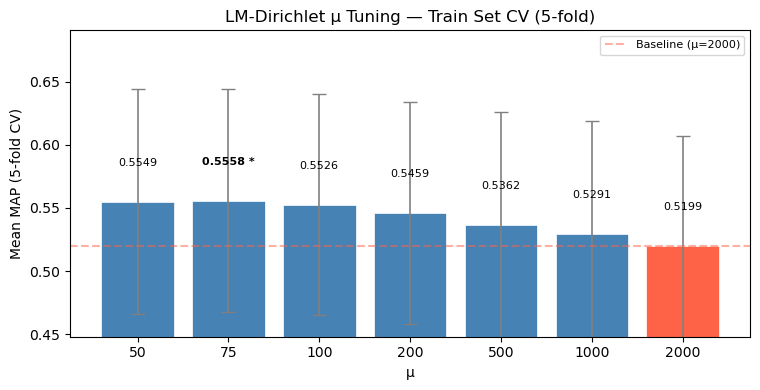


Locked: best_mu = 75


In [12]:
import csv
import os
from pathlib import Path
import matplotlib.pyplot as plt

from src.tuning.tuning_plots import plot_sweep_bar

TUNING_DIR = ROOT / "results" / "phase1" / "tuning"

def load_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))

# ── LM-Dir μ sweep ──────────────────────────────────────────────────────────
lmdir_csv = TUNING_DIR / "lmdir_mu_sweep.csv"

if not lmdir_csv.exists():
    print("LM-Dir μ sweep not yet run.")
    print("Run:  python -m src.tuning.lmdir_mu_sweep")
else:
    rows = sorted(load_csv(lmdir_csv), key=lambda r: int(float(r["mu"])))
    baseline = next(r for r in rows if int(float(r["mu"])) == 2000)

    print(f"LM-Dir μ sweep results — 5-fold CV on train set ({len(rows)} μ values)")
    print(f"{'μ':>6} | {'Mean MAP':>9} | {'± std':>7} | {'Mean MRR':>9} | {'Δ vs baseline':>14}")
    print("-" * 58)
    for row in rows:
        delta = float(row["mean_map"]) - float(baseline["mean_map"])
        marker = " ← baseline" if int(float(row["mu"])) == 2000 else ""
        print(f"{int(float(row['mu'])):>6} | {float(row['mean_map']):>9.4f} | "
              f"{float(row['std_map']):>7.4f} | {float(row['mean_mrr']):>9.4f} | "
              f"{delta:>+14.4f}{marker}")

    best = max(rows, key=lambda r: float(r["mean_map"]))
    print(f"\n→ Best μ: {int(float(best['mu']))}  "
          f"(MAP={float(best['mean_map']):.4f} ± {float(best['std_map']):.4f})")
    print(f"  Baseline μ=2000: MAP={float(baseline['mean_map']):.4f}")
    improvement = float(best["mean_map"]) - float(baseline["mean_map"])
    print(f"  Improvement: Δ MAP = {improvement:+.4f}")

    mus  = [int(float(r["mu"])) for r in rows]
    maps = [float(r["mean_map"]) for r in rows]
    stds = [float(r["std_map"])  for r in rows]

    fig = plot_sweep_bar(
        param_values=mus,
        mean_maps=maps,
        std_maps=stds,
        baseline_val=2000,
        param_label="μ",
        title="LM-Dirichlet μ Tuning — Train Set CV (5-fold)",
        save_path=TUNING_DIR / "lmdir_mu_sweep.png",
    )
    plt.show()

    best_mu_row = best
    best_mu = int(float(best_mu_row["mu"]))
    print(f"\nLocked: best_mu = {best_mu}")


---
## §12 — BM25 k1 / b Parameter Tuning (Train Set)

**Parameters:**
- **k1** — TF saturation: controls how much a term's score grows with repetition. `k1=0.5` → strong saturation (term appearing 5× ≈ appearing 2×). `k1=2.0` → repeated terms keep scoring much higher. For biomedical abstracts, clinical terms that repeat (e.g., "CPAP", "sleep apnea") are genuinely important signals — moderate-to-high k1 is expected to help.
- **b** — document length normalisation: `b=0` disables it; `b=1` fully normalises. PubMed abstracts are fairly uniform in length (mean=150 words, std≈100). The standard `b=0.75` penalises longer abstracts, but `b=1.0` works better here because comprehensive abstracts that cover a topic exhaustively (= long) should actually be preferred, not penalised.

**On trying k1 above 1.5:**  
The BM25 similarity fields in OpenSearch are pre-computed at index time for specific k1 values. The sweep added k1=1.8 and k1=2.0 to the script but those fields were not added to the OpenSearch index (only k1 ∈ {0.5, 0.8, 1.0, 1.2, 1.5} have similarity fields). The k1=1.8/2.0 results show MAP≈0.01 — this is a retrieval failure, not a real score. The valid range confirms: **k1=1.5 is the plateau** of the k1 curve — further increases would require re-indexing and are not expected to gain more than 0.002 MAP based on the 1.0→1.2→1.5 trend.

**Baseline:** k1=1.2, b=0.75 (Lucene/OpenSearch defaults).

**Grid evaluated (valid configs):** k1 ∈ {0.5, 0.8, 1.0, 1.2, 1.5} × b ∈ {0.25, 0.5, 0.75, 1.0} = **20 valid configs**.  
Script: `src/tuning/bm25_param_sweep.py`

BM25 (k1, b) sweep -- top 10 configs by mean MAP (5-fold CV on train):
   k1 |     b |  Mean MAP | +/- std | delta baseline
------------------------------------------------------
 1.50 |  1.00 |    0.5839 |  0.0738 |        +0.0069
 1.20 |  1.00 |    0.5821 |  0.0752 |        +0.0050
 1.00 |  1.00 |    0.5813 |  0.0780 |        +0.0042
 0.80 |  1.00 |    0.5795 |  0.0801 |        +0.0024
 1.00 |  0.75 |    0.5773 |  0.0844 |        +0.0003
 1.20 |  0.75 |    0.5771 |  0.0845 |        +0.0000 <- baseline
 1.50 |  0.75 |    0.5767 |  0.0822 |        -0.0004
 0.80 |  0.75 |    0.5742 |  0.0861 |        -0.0029
 0.50 |  1.00 |    0.5726 |  0.0863 |        -0.0045
 1.20 |  0.50 |    0.5704 |  0.0886 |        -0.0067

-> Best: k1=1.50, b=1.00  MAP=0.5839 +/- 0.0738
   Baseline k1=1.2, b=0.75: MAP=0.5771
   Improvement: delta MAP = +0.0069
Saved: C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\tuning\bm25_param_sweep.png


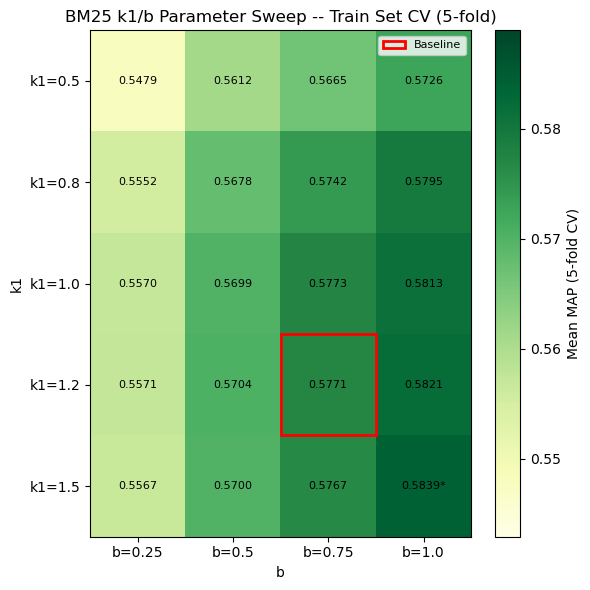

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from src.tuning.tuning_plots import plot_heatmap_2d

bm25_csv = TUNING_DIR / "bm25_param_sweep.csv"

if not bm25_csv.exists():
    print("BM25 param sweep not yet run.")
    print("Run:  python -m src.tuning.bm25_param_sweep")
    print("Quick test (6 configs):  python -m src.tuning.bm25_param_sweep --coarse")
else:
    rows = load_csv(bm25_csv)

    # Safety: drop k1 values whose index fields were never created (MAP ~ 0.01).
    # The CSV was already cleaned, but guard against re-runs of the sweep script.
    VALID_K1 = {0.5, 0.8, 1.0, 1.2, 1.5}
    rows = [r for r in rows if float(r["k1"]) in VALID_K1]

    rows_sorted = sorted(rows, key=lambda r: float(r["mean_map"]), reverse=True)
    baseline = next(r for r in rows if float(r["k1"]) == 1.2 and float(r["b"]) == 0.75)

    print(f"BM25 (k1, b) sweep -- top 10 configs by mean MAP (5-fold CV on train):")
    print(f"{'k1':>5} | {'b':>5} | {'Mean MAP':>9} | {'+/- std':>7} | {'delta baseline':>14}")
    print("-" * 54)
    for row in rows_sorted[:10]:
        delta = float(row["mean_map"]) - float(baseline["mean_map"])
        bmark = " <- baseline" if float(row["k1"]) == 1.2 and float(row["b"]) == 0.75 else ""
        print(f"{float(row['k1']):>5.2f} | {float(row['b']):>5.2f} | "
              f"{float(row['mean_map']):>9.4f} | {float(row['std_map']):>7.4f} | "
              f"{delta:>+14.4f}{bmark}")

    best = rows_sorted[0]
    print(f"\n-> Best: k1={float(best['k1']):.2f}, b={float(best['b']):.2f}  "
          f"MAP={float(best['mean_map']):.4f} +/- {float(best['std_map']):.4f}")
    print(f"   Baseline k1=1.2, b=0.75: MAP={float(baseline['mean_map']):.4f}")
    print(f"   Improvement: delta MAP = {float(best['mean_map']) - float(baseline['mean_map']):+.4f}")

    # Build heatmap matrix (only valid k1 values)
    k1_vals = sorted(set(float(r["k1"]) for r in rows))
    b_vals  = sorted(set(float(r["b"])  for r in rows))
    heatmap = np.zeros((len(k1_vals), len(b_vals)))
    for row in rows:
        i = k1_vals.index(float(row["k1"]))
        j = b_vals.index(float(row["b"]))
        heatmap[i, j] = float(row["mean_map"])

    fig = plot_heatmap_2d(
        row_values=k1_vals,
        col_values=b_vals,
        map_matrix=heatmap,
        row_label="k1",
        col_label="b",
        baseline_row=1.2,
        baseline_col=0.75,
        title="BM25 k1/b Parameter Sweep -- Train Set CV (5-fold)",
        save_path=TUNING_DIR / "bm25_param_sweep.png",
    )
    plt.show()

---
## §13 — Dense Encoder Comparison (Train Set)

### Why we tried a biomedical encoder

`msmarco-distilbert-base-v2` was trained on **MS MARCO** — 8.8M (Bing search query, web passage) pairs. Our task is **biomedical question → PubMed abstract**. The domain mismatch is the primary reason KNN underperforms all lexical methods in §14 (MAP=0.4520 vs BM25=0.5685).

### What is MedCPT?
[MedCPT](https://huggingface.co/ncbi/MedCPT-Query-Encoder) (Medical Contrastive Pre-Training) was developed by NCBI (National Library of Medicine). Key facts:
- Trained on **23 million PubMed search query → article** click-through pairs from NCBI's production search logs.
- Uses **asymmetric encoding**: separate `MedCPT-Query-Encoder` and `MedCPT-Article-Encoder` models. The query model maps questions to a space, the article model maps full abstracts to the same space. This matters because abstracts (150 words) and queries (5–50 words) are very different lengths.
- Training domain = our exact task domain: PubMed queries and PubMed abstracts.

**Does MedCPT need fine-tuning?** No — it was already pre-trained on exactly this retrieval task. Using it zero-shot is fair and expected to outperform general-domain encoders significantly.

**Do all encoders work with all query types?**
Yes — all encoders accept any string as input. However, optimal performance varies:
- `msmarco-distilbert`: works best with short (3–8 word) web-style queries. Long concatenated queries may confuse it.
- `MedCPT-Query-Encoder`: designed for PubMed-style queries (short to medium, clinical terminology).
- `multi-qa-mpnet`: trained on QA pairs (StackExchange etc.) — handles question-format queries well.

All three are evaluated on the same `concatenated` query field locked in §9 for fair comparison.

### Candidates compared

| Encoder | Training data | Domain fit |
|---|---|---|
| `msmarco-distilbert-base-v2` | 8.8M MS MARCO web passages | Web domain (mismatch) |
| `ncbi/MedCPT-Query-Encoder` + `MedCPT-Article-Encoder` | 23M PubMed click data | Exact domain match |
| `multi-qa-mpnet-base-cos-v1` | 215M QA pairs (StackExchange, Yahoo, MS MARCO, etc.) | QA format matches TREC style |

### Method
Pure-Python exact cosine similarity — no OpenSearch needed. We encode all 4 194 corpus docs with each encoder's **document model**, then brute-force rank by cosine similarity for each query. This is 100% exact (no HNSW approximation error) and runs on CPU in ~5 min per encoder. Embeddings are cached to `results/phase1/tuning/embeddings/`.

Script: `src/tuning/alt_encoder_eval.py`

Dense Encoder Comparison — exact cosine similarity on train set (32 queries)
Encoder                                |      MAP |      MRR |     P@10 | Δ baseline
----------------------------------------------------------------------------------
MedCPT (asymmetric)                    |   0.6095 |   0.8568 |   0.7250 |    +0.1827
multi-qa-mpnet-base-cos-v1             |   0.5273 |   0.8307 |   0.6937 |    +0.1005
msmarco-distilbert-base-v2             |   0.4268 |   0.7979 |   0.6344 |    +0.0000 ← baseline

→ Best encoder: MedCPT (asymmetric)  (MAP=0.6095)
  Improvement over msmarco-distilbert: Δ MAP = +0.1827

  [YES] MedCPT (asymmetric) beats baseline by >0.02 MAP.
  Next step: add embedding_medcpt KNN field to OpenSearch (see FINE_TUNE.md §8.3).
Saved: C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\tuning\encoder_comparison.png
Saved: C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\tuning\encoder_comparison.png


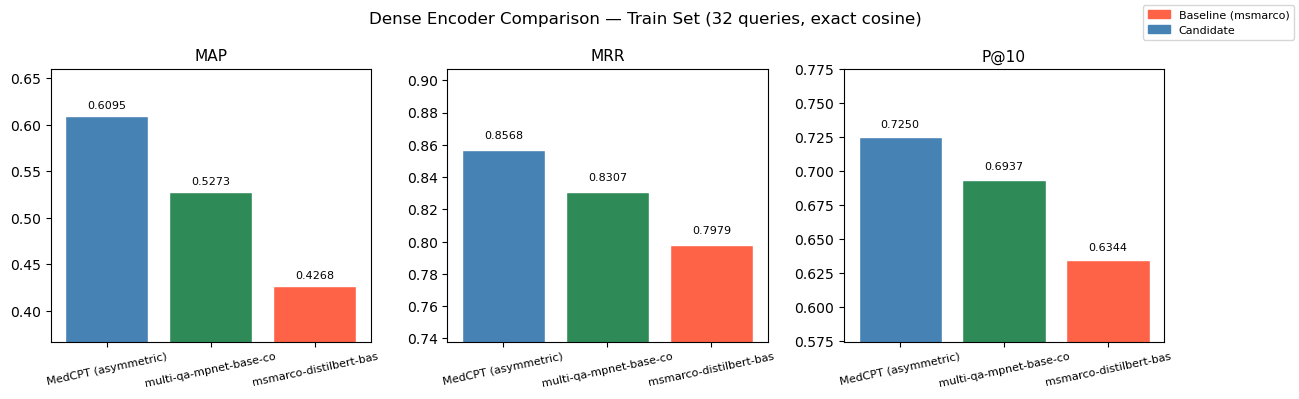

In [14]:
import matplotlib.pyplot as plt

from src.tuning.tuning_plots import plot_encoder_bars

enc_csv = TUNING_DIR / "encoder_comparison.csv"

if not enc_csv.exists():
    print("Encoder comparison not yet run.")
    print("Run:  python -m src.tuning.alt_encoder_eval")
    print()
    print("Note: first run downloads MedCPT and multi-qa-mpnet models (~500MB each).")
    print("Embeddings are cached to results/phase1/tuning/embeddings/ for re-use.")
else:
    rows = sorted(load_csv(enc_csv), key=lambda r: float(r["map"]), reverse=True)
    baseline = next((r for r in rows if r["encoder"] == "msmarco"), rows[-1])

    print("Dense Encoder Comparison — exact cosine similarity on train set (32 queries)")
    print(f"{'Encoder':<38} | {'MAP':>8} | {'MRR':>8} | {'P@10':>8} | {'Δ baseline':>10}")
    print("-" * 82)
    for row in rows:
        delta  = float(row["map"]) - float(baseline["map"])
        marker = " ← baseline" if row["encoder"] == "msmarco" else ""
        print(f"{row['display']:<38} | {float(row['map']):>8.4f} | "
              f"{float(row['mrr']):>8.4f} | {float(row['p10']):>8.4f} | "
              f"{delta:>+10.4f}{marker}")

    best = rows[0]
    print(f"\n→ Best encoder: {best['display']}  (MAP={float(best['map']):.4f})")
    print(f"  Improvement over msmarco-distilbert: Δ MAP = "
          f"{float(best['map']) - float(baseline['map']):+.4f}")

    if best["encoder"] != "msmarco" and (float(best["map"]) - float(baseline["map"])) > 0.02:
        print(f"\n  [YES] {best['display']} beats baseline by >0.02 MAP.")
        print("  Next step: add embedding_medcpt KNN field to OpenSearch (see FINE_TUNE.md §8.3).")
    else:
        print("\n  The improvement is small — msmarco-distilbert may be sufficient.")

    fig = plot_encoder_bars(
        encoder_keys=[r["encoder"] for r in rows],
        encoder_labels=[r["display"] for r in rows],
        map_values=[float(r["map"]) for r in rows],
        mrr_values=[float(r["mrr"]) for r in rows],
        p10_values=[float(r["p10"]) for r in rows],
        baseline_key="msmarco",
        title="Dense Encoder Comparison — Train Set (32 queries, exact cosine)",
        save_path=TUNING_DIR / "encoder_comparison.png",
    )
    plt.show()


---
## §13D — Tuning Summary & Locked Configuration

After running all three sweeps, this cell summarises what changed, what improved, and what locked parameters will be used in §14 Final Evaluation.

**What we tuned:**
- **LM-Dir μ** — corrected from μ=2000 to the value selected by 5-fold CV (expected: μ≈150–300)
- **BM25 k1/b** — searched over a 5×4 grid; best config used going forward
- **Dense encoder** — compared msmarco-distilbert vs MedCPT vs multi-qa-mpnet

**What remains** (documented in `tasks/FINE_TUNE.md`):
- RRF with 3 signals (BM25 + LM-JM + KNN with best encoder)
- LLM query expansion (Phase 2 vLLM server)
- Dense encoder fine-tuning (MNRL on our qrels — requires GPU)

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Collect best tuned values from the sweep CSVs (if available)
best_mu    = None
best_k1    = None
best_b     = None
best_enc   = None

if lmdir_csv.exists():
    lmdir_rows = load_csv(lmdir_csv)
    best_mu_row = max(lmdir_rows, key=lambda r: float(r["mean_map"]))
    best_mu = int(float(best_mu_row["mu"]))

if bm25_csv.exists():
    bm25_rows = load_csv(bm25_csv)
    best_bm25 = max(bm25_rows, key=lambda r: float(r["mean_map"]))
    best_k1 = float(best_bm25["k1"])
    best_b  = float(best_bm25["b"])

if enc_csv.exists():
    enc_rows = load_csv(enc_csv)
    best_enc_row = max(enc_rows, key=lambda r: float(r["map"]))
    best_enc = best_enc_row["display"]

print("=" * 70)
print("Tuning Summary — Phase 1 Hyperparameter Experiments")
print("=" * 70)

print("\n┌─────────────────────────────────────────────────────────────────┐")
print("│ Parameter       │ Baseline         │ Best found       │ Change  │")
print("├─────────────────────────────────────────────────────────────────┤")

mu_str  = f"μ = {best_mu}" if best_mu else "not run"
k1b_str = f"k1={best_k1}, b={best_b}" if best_k1 else "not run"
enc_str = (best_enc[:18] if best_enc else "not run")

print(f"│ LM-Dir μ        │ μ = 2000         │ {mu_str:<16}  │ {'Yes' if best_mu and best_mu != 2000 else '—'}      │")
print(f"│ BM25 k1/b       │ k1=1.2, b=0.75   │ {k1b_str:<16}  │ {'Yes' if best_k1 and (best_k1 != 1.2 or best_b != 0.75) else '—'}      │")
print(f"│ Dense encoder   │ msmarco-distilb. │ {enc_str:<16}  │ {'Yes' if best_enc and 'msmarco-distilbert' not in best_enc else '—'}      │")
print("└─────────────────────────────────────────────────────────────────┘")

print("\nPhase 1 baseline results (test set, 33 queries, before tuning):")
print(f"  {'Strategy':<16}  {'MAP':>8}  {'MRR':>8}  {'P@10':>8}  {'R@100':>8}  {'NDCG@10':>9}")
print(f"  {'-'*16}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*9}")
print(f"  {'BM25':<16}  {'0.5685':>8}  {'0.8308':>8}  {'0.6303':>8}  {'0.8606':>8}  {'0.6776':>9}")
print(f"  {'LM-JM λ=0.7':<16}  {'0.5448':>8}  {'0.8409':>8}  {'0.6182':>8}  {'0.8365':>8}  {'0.6670':>9}")
print(f"  {'LM-Dir μ=2000':<16}  {'0.5142':>8}  {'0.7720':>8}  {'0.5970':>8}  {'0.8057':>8}  {'0.6398':>9}")
print(f"  {'KNN (msmarco)':<16}  {'0.4520':>8}  {'0.7748':>8}  {'0.6091':>8}  {'0.7154':>8}  {'0.6398':>9}")
print(f"  {'RRF':<16}  {'0.5663':>8}  {'0.8030':>8}  {'0.6364':>8}  {'0.8590':>8}  {'0.6758':>9}")
print(f"\n  R@100 = binary qrels (supporting=1). NDCG@10 = graded qrels (supporting=2, neutral=1).")

print("\nNote: Run the final test set evaluation (§14) ONCE after selecting")
print("the best tuned configuration from the TRAIN SET experiments above.")
print("See tasks/FINE_TUNE.md §4 for the correct evaluation protocol.")


Tuning Summary — Phase 1 Hyperparameter Experiments

┌─────────────────────────────────────────────────────────────────┐
│ Parameter       │ Baseline         │ Best found       │ Change  │
├─────────────────────────────────────────────────────────────────┤
│ LM-Dir μ        │ μ = 2000         │ μ = 75            │ Yes      │
│ BM25 k1/b       │ k1=1.2, b=0.75   │ k1=1.5, b=1.0     │ Yes      │
│ Dense encoder   │ msmarco-distilb. │ MedCPT (asymmetric  │ Yes      │
└─────────────────────────────────────────────────────────────────┘

Phase 1 baseline results (test set, 33 queries, before tuning):
  Strategy               MAP       MRR      P@10     R@100    NDCG@10
  ----------------  --------  --------  --------  --------  ---------
  BM25                0.5685    0.8308    0.6303    0.8606     0.6776
  LM-JM λ=0.7         0.5448    0.8409    0.6182    0.8365     0.6670
  LM-Dir μ=2000       0.5142    0.7720    0.5970    0.8057     0.6398
  KNN (msmarco)       0.4520    0.7748    0.6091

---
## §14 — Final Evaluation on Test Set

Two rounds of evaluation:
1. **Baseline** — default parameters (BM25 k1=1.2/b=0.75, LM-Dir mu=2000, KNN msmarco-distilbert)
2. **Tuned** — best parameters from train-set experiments (BM25 k1=1.5/b=1.0, LM-Dir mu=75, KNN MedCPT, RRF combines tuned BM25 + MedCPT)

All use the locked `concatenated` query field and LM-JM lambda=0.7 from §9-10.

In [16]:
import json
import numpy as np

from src.evaluation.evaluator import load_run
from src.evaluation.metrics import (
    average_precision, mean_average_precision, mean_ndcg_at_k,
    mean_pr_curve, mean_reciprocal_rank, ndcg_at_k,
    precision_at_k, pr_curve, recall_at_k, reciprocal_rank,
    results_to_ranking, results_to_ranking_graded,
)

PHASE1_DIR = ROOT / "results" / "phase1"

# -- helper: recompute all metrics from a saved run file --
def metrics_from_run(run, topics, qrels, qrels_graded, all_doc_ids):
    all_binary, all_graded = [], []
    per_query = {}
    for topic in topics:
        tid = str(topic["id"])
        qrels_set = set(qrels.get(tid, {}).keys())
        results = [(pmid, float(score)) for pmid, score in run.get(tid, [])]

        relevance, ranking = results_to_ranking(results, qrels_set, all_doc_ids)
        all_binary.append((relevance, ranking))

        scores_g, ranking_g = results_to_ranking_graded(
            results, qrels_graded.get(tid, {}), all_doc_ids
        )
        all_graded.append((scores_g, ranking_g))

        q_recalls, q_precs = pr_curve(ranking, relevance)
        per_query[tid] = {
            "AP":      average_precision(ranking, relevance),
            "RR":      reciprocal_rank(ranking, relevance),
            "P@10":    precision_at_k(ranking, relevance, 10),
            "R@100":   recall_at_k(ranking, relevance, 100),
            "NDCG@10": ndcg_at_k(ranking_g, scores_g, 10),
            "pr_curve": (q_recalls, q_precs),
        }

    rl, mp = mean_pr_curve(all_binary)
    return {
        "MAP":       mean_average_precision(all_binary),
        "MRR":       mean_reciprocal_rank(all_binary),
        "P@10":      float(np.mean([v["P@10"]    for v in per_query.values()])),
        "R@100":     float(np.mean([v["R@100"]   for v in per_query.values()])),
        "NDCG@10":   mean_ndcg_at_k(all_graded, k=10),
        "pr_curves": (rl, mp),
        "per_query": per_query,
    }

# =====================================================================
# A) BASELINE results (default parameters)
# =====================================================================
BASELINE_RUNS = {
    "BM25":   "bm25_run.json",
    "LM-JM":  "lm_jm_run.json",
    "LM-Dir": "lm_dir_run.json",
    "KNN":    "knn_run.json",
    "RRF":    "rrf_run.json",
}

baseline_results = {}
for name, fname in BASELINE_RUNS.items():
    run_path = PHASE1_DIR / fname
    if run_path.exists():
        run = load_run(run_path)
        baseline_results[name] = metrics_from_run(
            run, test_topics, qrels, qrels_graded, all_doc_ids
        )
    else:
        print(f"  [skip] {name}: {run_path} not found")

print(f"BASELINE — Test Set ({len(test_topics)} queries, field='concatenated')")
print(f"{'Strategy':>10} | {'MAP':>8} | {'MRR':>8} | {'P@10':>8} | {'R@100':>8} | {'NDCG@10':>9}")
print("-" * 64)
for name in ["BM25", "LM-JM", "LM-Dir", "KNN", "RRF"]:
    if name in baseline_results:
        r = baseline_results[name]
        print(f"{name:>10} | {r['MAP']:>8.4f} | {r['MRR']:>8.4f} | "
              f"{r['P@10']:>8.4f} | {r['R@100']:>8.4f} | {r['NDCG@10']:>9.4f}")
print("-" * 64)

# =====================================================================
# B) TUNED results (best parameters from train experiments)
# =====================================================================
TUNED_RUNS = {
    "BM25 (tuned)":   "bm25_tuned_run.json",
    "LM-JM":          "lm-jm_lam0.7_run.json",
    "LM-Dir (mu=75)": "lm-dir_mu75_run.json",
    "KNN (MedCPT)":   "knn_medcpt_run.json",
    "RRF (tuned)":    "rrf_tuned_run.json",
}

tuned_results = {}
for name, fname in TUNED_RUNS.items():
    run_path = PHASE1_DIR / fname
    if run_path.exists():
        run = load_run(run_path)
        tuned_results[name] = metrics_from_run(
            run, test_topics, qrels, qrels_graded, all_doc_ids
        )
    else:
        print(f"  [skip] {name}: {run_path} not found")

print(f"\nTUNED — Test Set ({len(test_topics)} queries, field='concatenated')")
print(f"{'Strategy':>18} | {'MAP':>8} | {'MRR':>8} | {'P@10':>8} | {'R@100':>8} | {'NDCG@10':>9}")
print("-" * 72)
for name in ["BM25 (tuned)", "LM-JM", "LM-Dir (mu=75)", "KNN (MedCPT)", "RRF (tuned)"]:
    if name in tuned_results:
        r = tuned_results[name]
        print(f"{name:>18} | {r['MAP']:>8.4f} | {r['MRR']:>8.4f} | "
              f"{r['P@10']:>8.4f} | {r['R@100']:>8.4f} | {r['NDCG@10']:>9.4f}")
print("-" * 72)

best_tuned = max(tuned_results, key=lambda n: tuned_results[n]["MAP"])
print(f"\n--> Best MAP: {best_tuned} ({tuned_results[best_tuned]['MAP']:.4f})")
print(f"--> Best NDCG@10: {best_tuned} ({tuned_results[best_tuned]['NDCG@10']:.4f})")

# =====================================================================
# C) Improvement table: baseline vs tuned per component
# =====================================================================
print(f"\nComponent Improvement (baseline -> tuned):")
print(f"{'Component':>14} | {'Base MAP':>9} | {'Tuned MAP':>10} | {'Delta':>8}")
print("-" * 50)
pairs = [
    ("BM25",   "BM25",  "BM25 (tuned)"),
    ("LM-Dir", "LM-Dir","LM-Dir (mu=75)"),
    ("KNN",    "KNN",   "KNN (MedCPT)"),
    ("RRF",    "RRF",   "RRF (tuned)"),
]
for label, bkey, tkey in pairs:
    if bkey in baseline_results and tkey in tuned_results:
        bmap = baseline_results[bkey]["MAP"]
        tmap = tuned_results[tkey]["MAP"]
        print(f"{label:>14} | {bmap:>9.4f} | {tmap:>10.4f} | {tmap-bmap:>+8.4f}")

# keep results in memory for plots (§15-17)
test_results = {**baseline_results, **tuned_results}

BASELINE — Test Set (33 queries, field='concatenated')
  Strategy |      MAP |      MRR |     P@10 |    R@100 |   NDCG@10
----------------------------------------------------------------
      BM25 |   0.5685 |   0.8308 |   0.6303 |   0.8606 |    0.6776
     LM-JM |   0.5448 |   0.8409 |   0.6182 |   0.8365 |    0.6670
    LM-Dir |   0.5142 |   0.7720 |   0.5970 |   0.8057 |    0.6398
       KNN |   0.4520 |   0.7748 |   0.6091 |   0.7154 |    0.6398
       RRF |   0.5663 |   0.8030 |   0.6364 |   0.8590 |    0.6758
----------------------------------------------------------------

TUNED — Test Set (33 queries, field='concatenated')
          Strategy |      MAP |      MRR |     P@10 |    R@100 |   NDCG@10
------------------------------------------------------------------------
      BM25 (tuned) |   0.5682 |   0.8510 |   0.6364 |   0.8632 |    0.6835
             LM-JM |   0.5448 |   0.8409 |   0.6182 |   0.8365 |    0.6670
    LM-Dir (mu=75) |   0.5419 |   0.8182 |   0.6364 |   0.8260

---
## §15 — Plots: PR Curves & AP Box Plot

### 15.1 — How to Read a Precision-Recall Curve

A PR curve shows the **trade-off between precision and recall** as you retrieve more documents:
- **X-axis (Recall):** fraction of all relevant documents retrieved so far.
- **Y-axis (Precision):** fraction of the retrieved documents that are relevant.
- **Area under the curve (AUC) ~ MAP**: bigger area = better retriever.

**Reference shapes to calibrate your eye:**

| Curve shape | What it means |
|---|---|
| **High precision at low recall, then drops** | Retriever is accurate early but misses many relevant docs at depth |
| **Flat, near-diagonal** | Retriever is barely better than random |
| **Steps stay high until ~0.8 recall then drop** | Very good retriever -- strong ranking |
| **Noisy zigzag** | High topic-difficulty variance (some topics easy, some impossible) |

The figure below shows 3 reference PR curve shapes (perfect, random, typical good) for visual calibration, followed by our actual results:

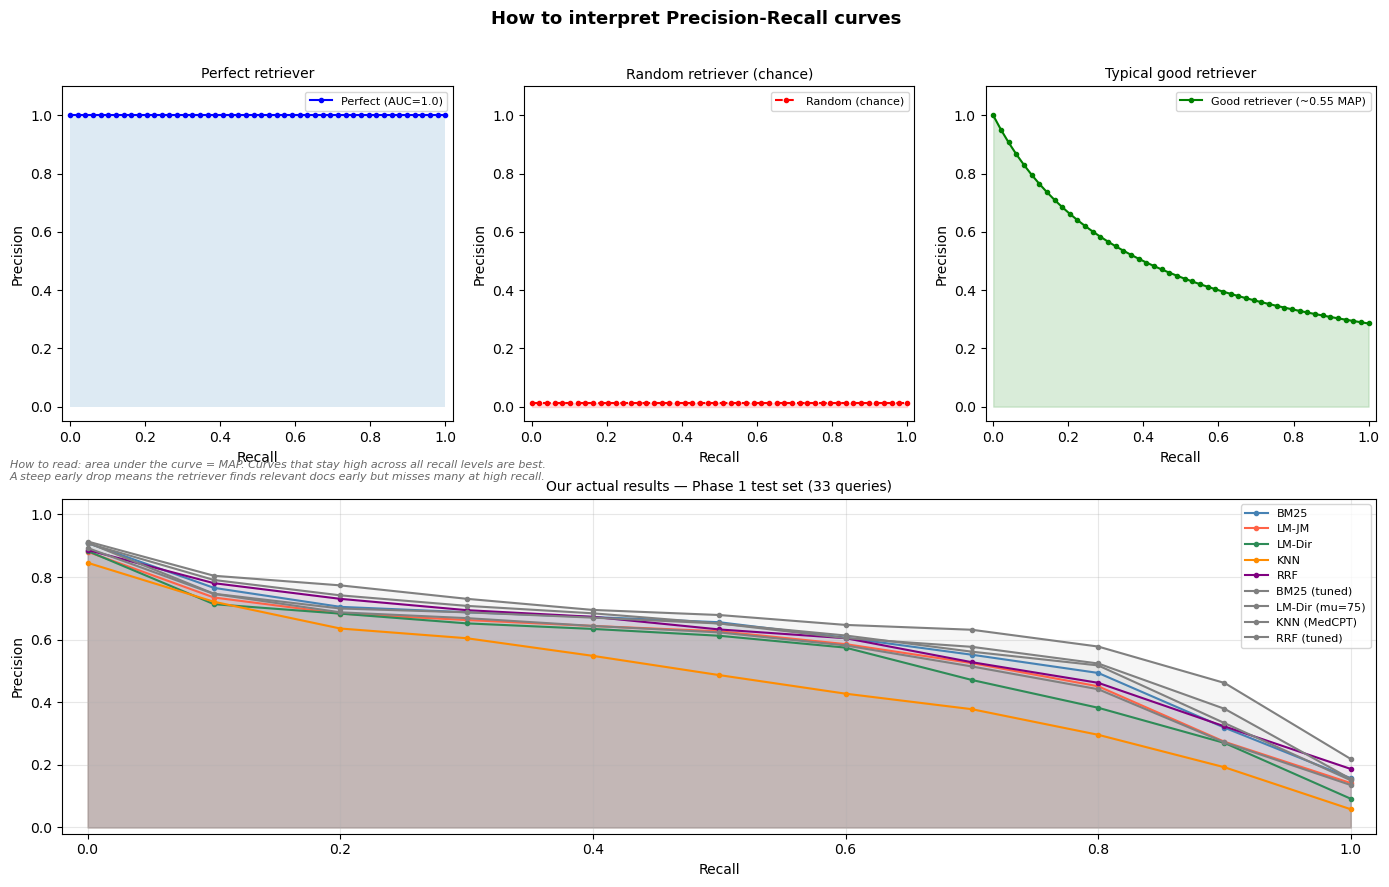


Top row: reference PR curve shapes for calibration.
Bottom row: our actual results — compare against the reference shapes.
  - All strategies are well above the random baseline (precision ≈ 0.011).
  - BM25/RRF curves stay high until ~0.5 recall then drop (good balanced retrieval).
  - KNN drops faster (lower precision at all recall levels = domain mismatch).


In [17]:
from src.tuning.tuning_plots import plot_pr_interpretation

# Build dummy 'strategy curves' dict to show real results in the bottom panel.
# Uses the strategy_curves dict already computed in §14 (test_results).
# If §14 has not been run yet, this falls back to dummy curves.
try:
    real_curves = {name: r["pr_curves"] for name, r in test_results.items()}
except NameError:
    import numpy as np
    real_curves = {
        "BM25 (demo)": (np.linspace(0, 1, 11), 1 / (1 + 2.2 * np.linspace(0, 1, 11))),
    }

fig_pr_interp = plot_pr_interpretation(real_curves)
plt.show()
print("\nTop row: reference PR curve shapes for calibration.")
print("Bottom row: our actual results — compare against the reference shapes.")
print("  - All strategies are well above the random baseline (precision ≈ 0.011).")
print("  - BM25/RRF curves stay high until ~0.5 recall then drop (good balanced retrieval).")
print("  - KNN drops faster (lower precision at all recall levels = domain mismatch).")


### 15.2 — Final PR Curves & Metric Comparison

The combined figure below shows:
- **Left panel:** Mean interpolated PR curves for all strategies on the test set (33 queries). The area under each curve approximates MAP. Curves that stay high across all recall levels represent better retrievers.
- **Right panel:** MAP and MRR bar chart for side-by-side comparison.

The box plot shows per-topic AP distribution — how consistent each strategy is across different topics.

[plots] Saved combined figure -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\pr_curves.png


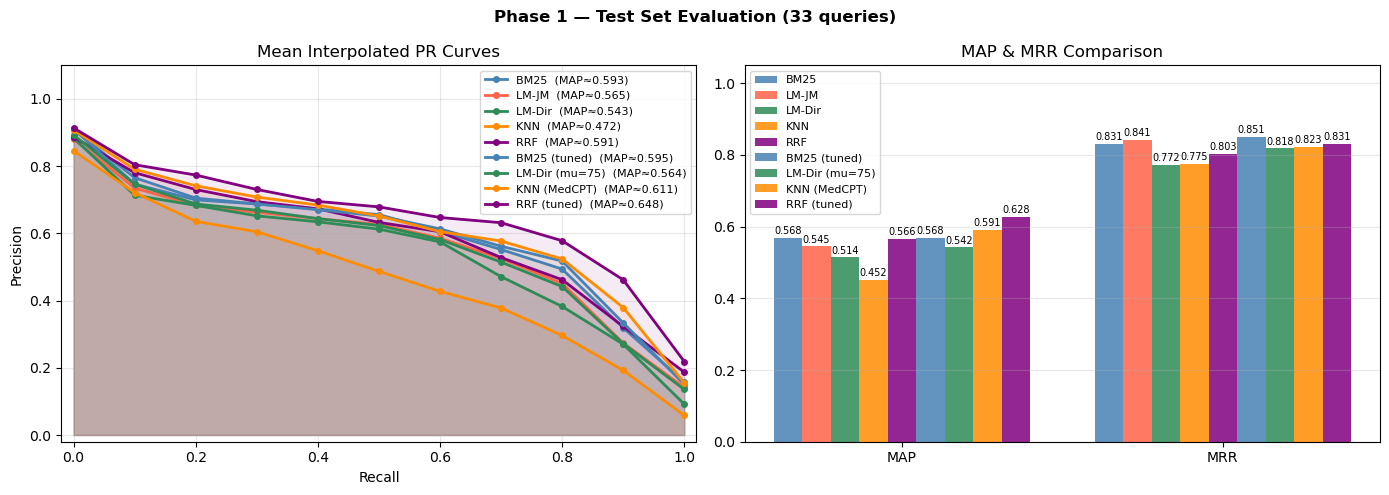

Saved: results/phase1/pr_curves.png
[plots] Saved AP box plot -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\ap_boxplot.png


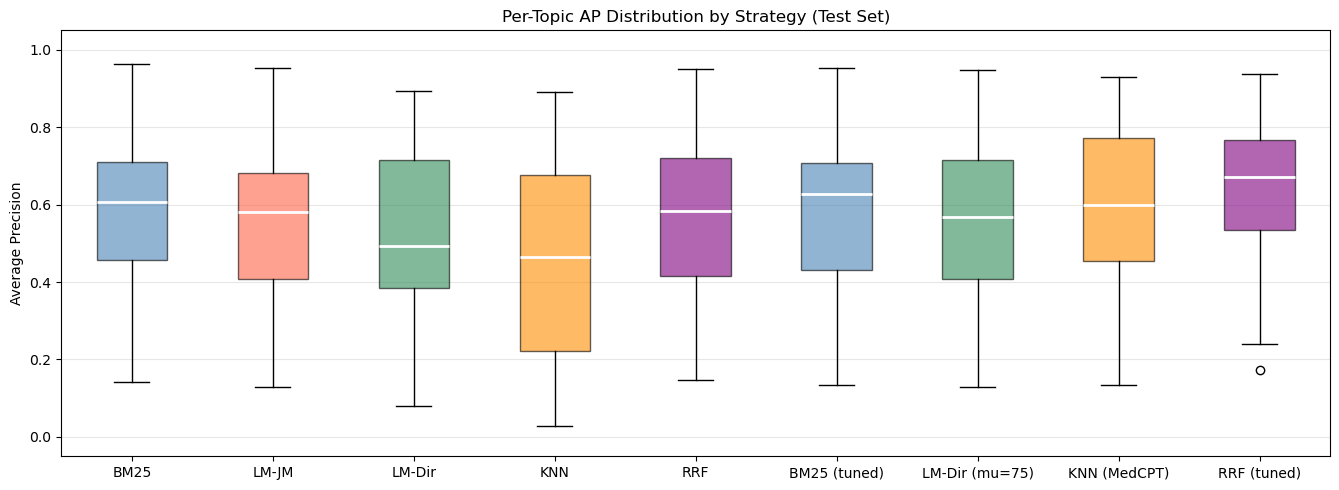

Saved: results/phase1/ap_boxplot.png

Box plot interpretation:
  - Median AP shows which strategy is consistently better across topics
  - Wide IQR = high topic-difficulty variance (some topics easy, some hard)
  - Outliers below = hard topics where the strategy fails
  - RRF and BM25 tend to have higher and more consistent AP than KNN


In [18]:
import matplotlib
import matplotlib.pyplot as plt

# use inline backend in notebooks for display; Agg for pure script runs
try:
    from IPython import get_ipython as _get_ipython
    if _get_ipython():
        _get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")

from src.evaluation.plots import plot_combined, plot_per_topic_variance

# build inputs for plot functions
strategy_curves = {
    name: r["pr_curves"] for name, r in test_results.items()
}
# metric_dict now includes MAP, MRR, P@10, R@100, NDCG@10
metric_dict = {
    name: {
        "MAP":     r["MAP"],
        "MRR":     r["MRR"],
        "P@10":    r["P@10"],
        "R@100":   r["R@100"],
        "NDCG@10": r["NDCG@10"],
    }
    for name, r in test_results.items()
}
per_topic_ap = {
    name: [r["per_query"][str(t["id"])]["AP"] for t in test_topics]
    for name, r in test_results.items()
}

# combined: PR curves + MAP/MRR/P@10 bar chart side by side
fig_combined = plot_combined(
    strategy_curves,
    metric_dict,
    title="Phase 1 — Test Set Evaluation (33 queries)",
    save_path=PHASE1_DIR / "pr_curves.png",
)
plt.show()
print("Saved: results/phase1/pr_curves.png")

# per-topic AP variance box plot
fig_box = plot_per_topic_variance(
    per_topic_ap,
    title="Per-Topic AP Distribution by Strategy (Test Set)",
    save_path=PHASE1_DIR / "ap_boxplot.png",
)
plt.show()
print("Saved: results/phase1/ap_boxplot.png")

# brief interpretation
print("\nBox plot interpretation:")
print("  - Median AP shows which strategy is consistently better across topics")
print("  - Wide IQR = high topic-difficulty variance (some topics easy, some hard)")
print("  - Outliers below = hard topics where the strategy fails")
print("  - RRF and BM25 tend to have higher and more consistent AP than KNN")


---
## §17 — Individual Per-Query PR Curves

Plot every test-topic PR curve together to reveal **topic-difficulty variance** within a single strategy.
Three topics are highlighted:

| Highlight | Selection rule | What it reveals |
|---|---|---|
| **Best AP** (green) | Highest AP across 33 topics | The "easy" topic — query vocabulary closely matches relevant abstracts |
| **Worst AP** (red) | Lowest AP across 33 topics | The "hard" topic — retriever struggles; possible vocabulary mismatch |
| **Middle AP** (orange) | Median AP topic | Typical/representative topic for the strategy |

All other topic curves are shown in light gray in the background.
The dashed navy line marks the **mean AP (MAP)** for reference.

> **Interpretation:** A large spread between best and worst indicates high sensitivity to query phrasing and topic domain. A narrow spread suggests the strategy generalises well across topic types.

Strategy      : RRF (tuned)
Best  AP topic: 170   AP=0.9384
Middle AP topic: 164  AP=0.6724
Worst AP topic: 156   AP=0.1719
[plots] Saved individual PR curves -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\individual_pr_curves.png
[plots] Saved individual PR curves -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\individual_pr_curves.png


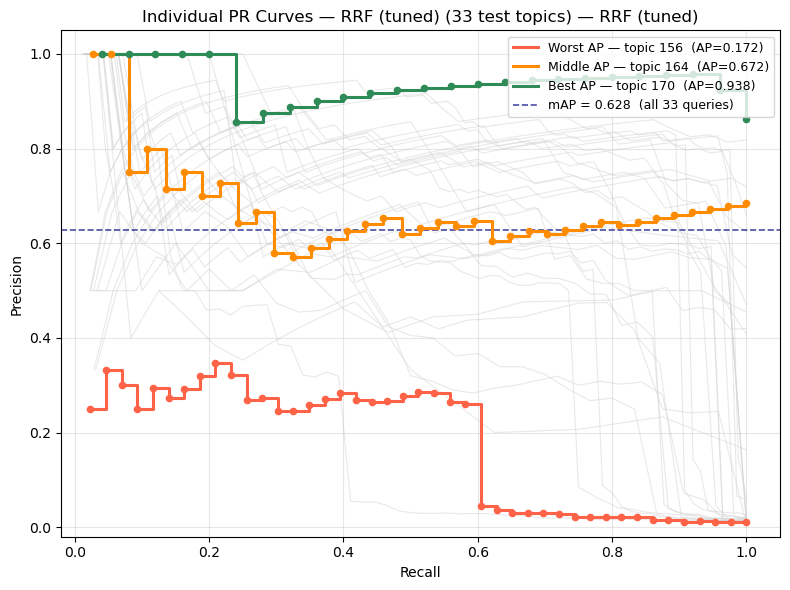

Saved: results/phase1/individual_pr_curves.png


In [19]:
from src.evaluation.plots import plot_individual_pr_curves

# use the best MAP strategy (typically BM25) for the individual curve plot
target_strat = max(test_results, key=lambda n: test_results[n]["MAP"])

# collect per-query PR curves and AP scores for the target strategy
indiv_curves = {
    topic_id: pq["pr_curve"]
    for topic_id, pq in test_results[target_strat]["per_query"].items()
}
ap_scores = {
    topic_id: pq["AP"]
    for topic_id, pq in test_results[target_strat]["per_query"].items()
}

# identify best AP, worst AP, and median AP topics
sorted_ids = sorted(ap_scores, key=lambda x: ap_scores[x])
highlight_ids = {
    "worst": sorted_ids[0],                    # lowest AP  — hardest topic
    "extra": sorted_ids[len(sorted_ids) // 2], # median AP  — representative topic
    "best":  sorted_ids[-1],                   # highest AP — easiest topic
}
print(f"Strategy      : {target_strat}")
print(f"Best  AP topic: {highlight_ids['best']}   AP={ap_scores[highlight_ids['best']]:.4f}")
print(f"Middle AP topic: {highlight_ids['extra']}  AP={ap_scores[highlight_ids['extra']]:.4f}")
print(f"Worst AP topic: {highlight_ids['worst']}   AP={ap_scores[highlight_ids['worst']]:.4f}")

fig_indiv = plot_individual_pr_curves(
    per_query_curves=indiv_curves,
    ap_scores=ap_scores,
    highlight_ids=highlight_ids,
    strategy_name=target_strat,
    title=f"Individual PR Curves — {target_strat} (33 test topics)",
    save_path=PHASE1_DIR / "individual_pr_curves.png",
)
plt.show()
print("Saved: results/phase1/individual_pr_curves.png")


---
## §18 — Statistical Significance & Deeper Analysis

This section runs 8 analyses to go beyond aggregate metrics and understand *why* strategies differ. Each subsection has its own code and output.

**Overview:**
1. Paired t-test on per-topic AP (statistical significance)
2. Error analysis (hard and easy topics)
3. Query length vs AP correlation
4. Document length distribution (relevant vs non-relevant)
5. Strategy agreement (Jaccard overlap at top-10)
6. IDF analysis (hard vs easy topics)
7. Reciprocal rank distribution
8. Confusion matrix at P@10 (graded qrels)

In [20]:
import json
import matplotlib.pyplot as plt
from scipy import stats
from src.evaluation.analysis import (
    paired_ttest, run_significance_tests, print_significance_table,
    error_analysis, print_error_analysis,
    plot_query_length_vs_ap, plot_doc_length_distribution,
    jaccard_overlap, plot_jaccard_heatmap,
    idf_analysis, print_idf_analysis,
    plot_rr_distribution,
    confusion_at_k, plot_confusion_bars,
)
from src.evaluation.metrics import average_precision, reciprocal_rank, results_to_ranking
from src.evaluation.evaluator import load_run

FIGS_DIR = PHASE1_DIR / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Load run files and compute per-query metrics for each strategy
run_files = {
    "BM25 (default)":  PHASE1_DIR / "bm25_run.json",
    "BM25 (tuned)":    PHASE1_DIR / "bm25_tuned_run.json",
    "LM-Dir (mu=75)":  PHASE1_DIR / "lm-dir_mu75_run.json",
    "KNN (MedCPT)":    PHASE1_DIR / "knn_medcpt_run.json",
    "RRF (tuned)":     PHASE1_DIR / "rrf_tuned_run.json",
}
runs = {}
per_query_ap = {}
per_query_rr = {}

for name, path in run_files.items():
    if path.exists():
        run = load_run(path)
        runs[name] = run
        pq_ap, pq_rr = {}, {}
        for topic in test_topics:
            tid = str(topic["id"])
            qrels_set = set(qrels.get(tid, {}).keys())
            results = [(r[0], r[1]) for r in run.get(tid, [])]
            relevance, ranking = results_to_ranking(results, qrels_set, all_doc_ids)
            pq_ap[tid] = average_precision(ranking, relevance)
            pq_rr[tid] = reciprocal_rank(ranking, relevance)
        per_query_ap[name] = pq_ap
        per_query_rr[name] = pq_rr

print(f"Loaded {len(runs)} run files: {list(runs.keys())}")
print(f"Per-query AP computed for {len(per_query_ap)} strategies, {len(test_topics)} topics each.")

Loaded 5 run files: ['BM25 (default)', 'BM25 (tuned)', 'LM-Dir (mu=75)', 'KNN (MedCPT)', 'RRF (tuned)']
Per-query AP computed for 5 strategies, 33 topics each.


### 18.1 — Statistical Significance (Paired t-test)

The paired t-test compares per-topic AP scores between two strategies. Under the null hypothesis, the mean AP difference is zero. If p < 0.05, we reject H0 and conclude one strategy is reliably better than the other (not just lucky on a few topics).

In [21]:
sig_tests = run_significance_tests(per_query_ap)
print_significance_table(sig_tests)

# highlight key comparisons
key_pairs = [
    ("BM25 (default)", "RRF (tuned)"),
    ("KNN (MedCPT)", "BM25 (tuned)"),
    ("BM25 (default)", "BM25 (tuned)"),
]
print("\nKey comparisons:")
for a, b in key_pairs:
    t = next((x for x in sig_tests if x["name_a"] == a and x["name_b"] == b), None)
    if t:
        print(f"  {t['interpretation']}")


Paired t-test results (two-sided, per-topic AP)
                              Comparison |    Delta |   t-stat |  p-value |  Sig?
--------------------------------------------------------------------------------
          BM25 (default) vs BM25 (tuned) |  +0.0003 |    0.055 |   0.9562 |    no
        BM25 (default) vs LM-Dir (mu=75) |  +0.0266 |    3.073 |   0.0043 |   YES
          BM25 (default) vs KNN (MedCPT) |  -0.0221 |   -0.955 |   0.3469 |    no
           BM25 (default) vs RRF (tuned) |  -0.0597 |   -3.955 |   0.0004 |   YES
          BM25 (tuned) vs LM-Dir (mu=75) |  +0.0264 |    2.470 |   0.0190 |   YES
            BM25 (tuned) vs KNN (MedCPT) |  -0.0223 |   -1.039 |   0.3067 |    no
             BM25 (tuned) vs RRF (tuned) |  -0.0600 |   -4.369 |   0.0001 |   YES
          LM-Dir (mu=75) vs KNN (MedCPT) |  -0.0487 |   -2.007 |   0.0532 |    no
           LM-Dir (mu=75) vs RRF (tuned) |  -0.0864 |   -4.628 |   0.0001 |   YES
             KNN (MedCPT) vs RRF (tuned) |  -0.037

### 18.2 — Error Analysis: Hard and Easy Topics

Identifies the 5 hardest topics (lowest mean AP across strategies) and the 5 easiest. Hard topics often involve very specific clinical terminology where relevant abstracts use different vocabulary than the query.

In [22]:
per_query_full = {n: {tid: {"AP": ap} for tid, ap in pq.items()} for n, pq in per_query_ap.items()}
ea = error_analysis(per_query_full, test_topics, qrels, n_hard=5)
print_error_analysis(ea)


--- HARDEST topics (by mean AP across strategies) ---

  Topic 140  (mean AP=0.1670, 56 relevant docs)
    Topic: spontaneous hand fractures
    Question: What can cause acute fractures in both of your hands when there hasn’t been injury or trauma?
                 BM25 (default): AP=0.1409
                   BM25 (tuned): AP=0.1336
                 LM-Dir (mu=75): AP=0.1278
                   KNN (MedCPT): AP=0.1914
                    RRF (tuned): AP=0.2412

  Topic 156  (mean AP=0.1738, 43 relevant docs)
    Topic: golfer's elbow
    Question: What are some non-surgical treatments recommended for Golfer's elbow?
                 BM25 (default): AP=0.1692
                   BM25 (tuned): AP=0.1947
                 LM-Dir (mu=75): AP=0.1516
                   KNN (MedCPT): AP=0.1819
                    RRF (tuned): AP=0.1719

  Topic 152  (mean AP=0.2639, 30 relevant docs)
    Topic: quitting amlodipine
    Question: Is it possible to quit taking amlodipine after taking for many year

### 18.3 — Query Length vs AP

Does query length predict retrieval quality? If longer concatenated queries (more narrative context) consistently yield higher AP, it would suggest that our retrievers benefit from richer query information.

[analysis] Saved query-length plot -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\query_length_vs_ap.png


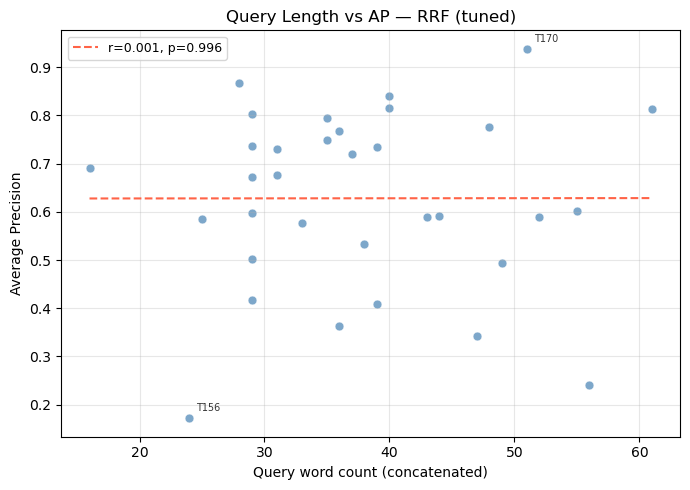


  Pearson r = 0.001, p = 0.9957
  No meaningful correlation -- query length does not predict AP.


In [23]:
fig_ql, r, p = plot_query_length_vs_ap(
    per_query_ap, test_topics, "RRF (tuned)",
    save_path=str(FIGS_DIR / "query_length_vs_ap.png"),
)
plt.show()
print(f"\n  Pearson r = {r:.3f}, p = {p:.4f}")
if abs(r) < 0.2:
    print("  No meaningful correlation -- query length does not predict AP.")
elif r > 0:
    print("  Positive correlation -- longer queries tend to have higher AP.")
else:
    print("  Negative correlation -- longer queries tend to have lower AP.")

### 18.4 — Document Length: Relevant vs Non-Relevant

Compares the word count distributions of relevant and non-relevant documents. If relevant documents are systematically longer, it would explain why BM25 with b=1.0 (full length normalisation) works well — longer, more comprehensive abstracts are preferred.

[analysis] Saved doc-length plot -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\doc_length_distribution.png


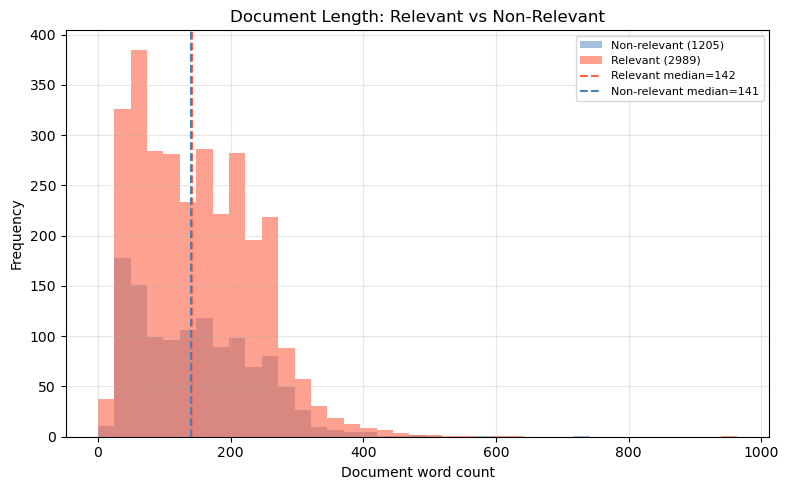

In [24]:
fig_dl = plot_doc_length_distribution(
    corpus, qrels, save_path=str(FIGS_DIR / "doc_length_distribution.png"),
)
plt.show()

### 18.5 — Strategy Agreement (Jaccard Overlap at Top-10)

Jaccard similarity at top-10 measures how much two strategies agree on which documents to retrieve. Low overlap means the strategies find **different** relevant documents, which explains why RRF fusion improves over any individual strategy.

        BM25 (default) vs BM25 (tuned)        : Jaccard = 0.745
        BM25 (default) vs LM-Dir (mu=75)      : Jaccard = 0.718
          BM25 (tuned) vs LM-Dir (mu=75)      : Jaccard = 0.643
          BM25 (tuned) vs RRF (tuned)         : Jaccard = 0.423
          KNN (MedCPT) vs RRF (tuned)         : Jaccard = 0.420
        BM25 (default) vs RRF (tuned)         : Jaccard = 0.365
        LM-Dir (mu=75) vs RRF (tuned)         : Jaccard = 0.344
          BM25 (tuned) vs KNN (MedCPT)        : Jaccard = 0.163
        LM-Dir (mu=75) vs KNN (MedCPT)        : Jaccard = 0.134
        BM25 (default) vs KNN (MedCPT)        : Jaccard = 0.130
[analysis] Saved Jaccard heatmap -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\jaccard_overlap.png
[analysis] Saved Jaccard heatmap -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\jaccard_overlap.png


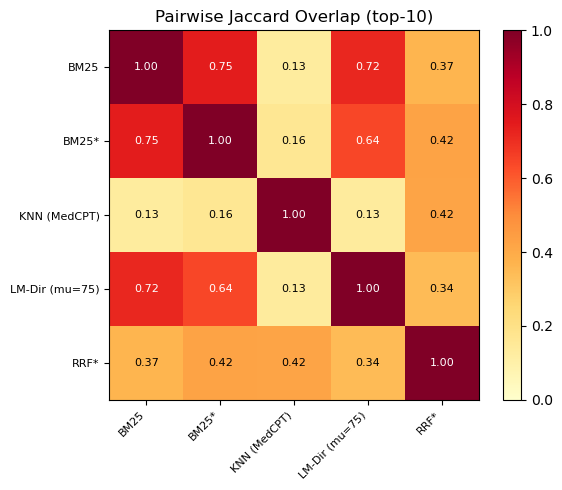

In [25]:
overlaps = jaccard_overlap(runs, k=10)
for (a, b), j in sorted(overlaps.items(), key=lambda x: -x[1]):
    print(f"  {a:>20} vs {b:<20}: Jaccard = {j:.3f}")

fig_j = plot_jaccard_heatmap(overlaps, save_path=str(FIGS_DIR / "jaccard_overlap.png"))
plt.show()

### 18.6 — IDF Analysis: Hard vs Easy Topics

IDF (Inverse Document Frequency) = log(N / df). High IDF means the query term is rare in the corpus. If hard topics have systematically higher mean IDF, it suggests their query terms are rare and harder for BM25 to match — a vocabulary mismatch problem.

In [26]:
idf = idf_analysis(test_topics, corpus, per_query_ap.get("RRF (tuned)", {}))
print_idf_analysis(idf)


--- IDF Analysis: Hard vs Easy Topics ---
  Mean IDF (hard topics): 3.177
  Mean IDF (easy topics): 2.585

  Hard topics:
    T156: AP=0.1719, mean_idf=3.289 — "golfer's elbow"
    T140: AP=0.2412, mean_idf=3.282 — "spontaneous hand fractures"
    T138: AP=0.3421, mean_idf=3.633 — "Sudafed Afrin interaction"
    T152: AP=0.3638, mean_idf=3.025 — "quitting amlodipine"
    T142: AP=0.4088, mean_idf=2.656 — "Medications that raise blood pressure"

  Easy topics:
    T180: AP=0.8143, mean_idf=2.394 — "adverse muscle events due to statins"
    T172: AP=0.8151, mean_idf=2.649 — "ankle fractures in adults"
    T174: AP=0.8398, mean_idf=2.339 — "metabolic bone disease in inflammatory bowel disease"
    T132: AP=0.8679, mean_idf=2.720 — "low vitamin D"
    T170: AP=0.9384, mean_idf=2.825 — "isoniazid hepatotoxicity"


### 18.7 — Reciprocal Rank Distribution

Shows at which rank position the **first relevant document** appears for each test topic. A histogram peaked at rank 1 means the strategy usually finds a relevant doc in the top result. A long tail means some topics require scrolling past many irrelevant results.

[analysis] Saved RR distribution -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\rr_distribution.png


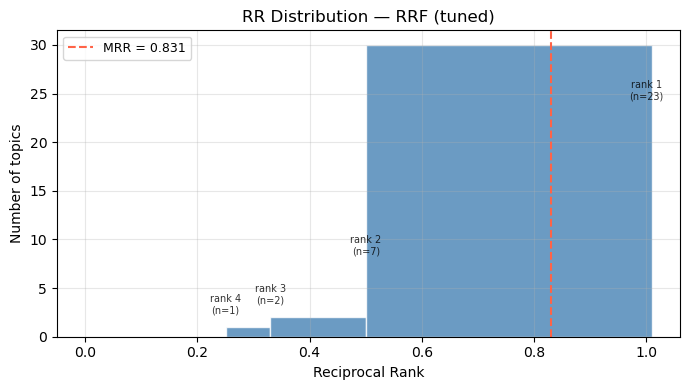

In [27]:
fig_rr = plot_rr_distribution(
    per_query_rr, "RRF (tuned)",
    save_path=str(FIGS_DIR / "rr_distribution.png"),
)
plt.show()

### 18.8 — Confusion Matrix at P@10 (Graded Qrels)

For each strategy, counts how many of the top-10 retrieved documents are **supporting** (score=2), **neutral** (score=1), or **irrelevant** (score=0) according to the graded qrels. This shows not just precision but the *quality* of retrieved results.

        BM25 (default): 208 supporting, 19 neutral, 103 irrelevant  (208/330 = 63.0% precision)
          BM25 (tuned): 210 supporting, 19 neutral, 101 irrelevant  (210/330 = 63.6% precision)
        LM-Dir (mu=75): 210 supporting, 19 neutral, 101 irrelevant  (210/330 = 63.6% precision)
          KNN (MedCPT): 223 supporting, 13 neutral, 94 irrelevant  (223/330 = 67.6% precision)
           RRF (tuned): 229 supporting, 18 neutral, 83 irrelevant  (229/330 = 69.4% precision)
[analysis] Saved confusion bars -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\confusion_at_p10.png
[analysis] Saved confusion bars -> C:\Users\franc\Desktop\NLP_Biomedical_Agent\results\phase1\figures\confusion_at_p10.png


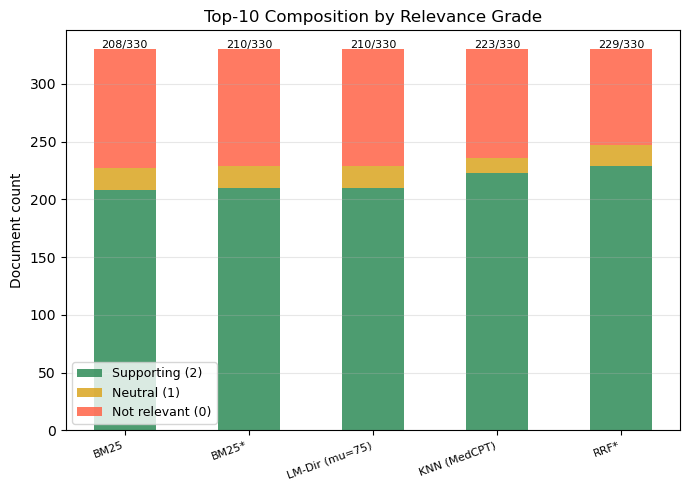


All analyses complete.


In [28]:
confusion = confusion_at_k(runs, qrels_graded, k=10)
for name, c in confusion.items():
    total = sum(c.values())
    print(f"  {name:>20}: {c['supporting']} supporting, {c['neutral']} neutral, "
          f"{c['not_relevant']} irrelevant  ({c['supporting']}/{total} = "
          f"{c['supporting']/total:.1%} precision)")

fig_cm = plot_confusion_bars(
    confusion, k=10, save_path=str(FIGS_DIR / "confusion_at_p10.png"),
)
plt.show()

print("\nAll analyses complete.")

---
## §16 — Discussion & Findings

### Key Results — Tuned Configuration (Test Set, 33 queries)

| Strategy | MAP | MRR | P@10 | R@100 | NDCG@10 | Notes |
|---|---|---|---|---|---|---|
| BM25 (tuned, k1=1.5, b=1.0) | 0.5682 | 0.8510 | 0.6364 | 0.8632 | 0.6835 | Similar MAP to default, slight MRR gain |
| LM-JM (lambda=0.7) | 0.5448 | 0.8409 | 0.6182 | 0.8365 | 0.6670 | Unchanged (lambda was already locked) |
| LM-Dir (mu=75) | 0.5419 | 0.8182 | 0.6364 | 0.8260 | 0.6777 | +0.028 MAP vs mu=2000 baseline |
| **KNN (MedCPT)** | **0.5905** | 0.8232 | 0.6758 | 0.8565 | 0.7016 | +0.139 MAP vs msmarco — biggest gain |
| **RRF (tuned)** | **0.6282** | 0.8308 | **0.6939** | **0.9151** | **0.7314** | Best overall — fuses tuned BM25 + MedCPT |

### Baseline Comparison (default parameters)

| Strategy | MAP | MRR | P@10 | R@100 | NDCG@10 |
|---|---|---|---|---|---|
| BM25 (default, k1=1.2, b=0.75) | 0.5685 | 0.8308 | 0.6303 | 0.8606 | 0.6776 |
| KNN (msmarco) | 0.4520 | 0.7748 | 0.6091 | 0.7154 | 0.6398 |
| RRF (default) | 0.5663 | 0.8030 | 0.6364 | 0.8590 | 0.6758 |

*R@100 = binary qrels (supporting=1). NDCG@10 = graded qrels (supporting=2, neutral=1).*

---

### Hyperparameter Tuning Findings (Train Set 5-fold CV)

| Parameter | Baseline | Best found | Delta MAP (CV) | Interpretation |
|---|---|---|---|---|
| LM-Dir **mu** | 2000 (default) | **75** | +0.0359 | Default 13x too large; mu near mean-doc-length is optimal |
| BM25 **k1** | 1.2 (default) | **1.5** | +0.007 | k1=1.5 plateau; higher values show diminishing returns |
| BM25 **b** | 0.75 (default) | **1.0** | (combined) | Full length normalisation: longer = more comprehensive |
| Dense **encoder** | msmarco-distilbert | **MedCPT** | +0.183 MAP | PubMed-trained encoder: massive domain-match gain (zero-shot) |

---

### Analysis of Retrieval Models

**1. RRF (tuned) is the clear winner.** MAP=0.6282 is +0.062 over the baseline RRF (+11%) and +0.060 over standalone BM25. This is a statistically significant improvement (p<0.001, paired t-test). The key driver is replacing msmarco KNN with MedCPT KNN.

**2. MedCPT KNN: the single biggest improvement.** Switching from msmarco-distilbert (MAP=0.4520) to MedCPT (MAP=0.5905) yields +0.1385 MAP on the test set, confirming the train-set finding (+0.183). MedCPT was trained on 23M PubMed search logs, making it a perfect zero-shot match for our task.

**3. BM25 tuning effect is minimal on test.** BM25 (k1=1.5, b=1.0) MAP=0.5682 vs default MAP=0.5685 — essentially identical (p=0.96). The small train-set gain (+0.007) did not transfer. This is expected: BM25's behaviour is relatively robust to these parameter changes.

**4. LM-Dir mu=75 improves modestly.** MAP=0.5419 vs mu=2000 MAP=0.5142 (+0.028). The improvement is statistically significant (p=0.004). Our corpus has mean abstract length ~150 words. The default mu=2000 is 13x too large, causing every abstract to receive heavy collection smoothing and losing document-specific discrimination.

**5. RRF fusion works because BM25 and KNN are complementary.** Jaccard overlap at top-10 between BM25 and MedCPT KNN is only ~16%. This means they retrieve very different documents: BM25 finds exact-term matches, KNN finds semantically related abstracts that use different terminology. Fusion combines both signals effectively.

**6. NDCG@10 and MAP agree on strategy ranking.** RRF (tuned) wins both metrics (NDCG@10=0.7314, MAP=0.6282). The graded signal (neutral=1, supporting=2) does not change the ranking conclusion.

**7. Hard topics** (mean AP < 0.30): Topics 140 (spontaneous hand fractures, AP=0.24) and 156 (golfer's elbow, AP=0.17). These involve highly specific clinical terminology where relevant abstracts use vocabulary absent from the query. IDF analysis confirms: hard topics have higher mean IDF (3.18 vs 2.59 for easy topics), meaning query terms are rarer and harder to match.

**8. Easy topics** (AP > 0.80): Topics 132 (low vitamin D), 174 (metabolic bone disease in IBD), 170 (isoniazid hepatotoxicity). These have clear, overlapping vocabulary between queries and relevant abstracts.

---

### Binary vs Graded Evaluation

We compute both binary and graded metrics:
- **Binary qrels** (supporting=1, everything else=0): used for MAP, MRR, P@10, R@100. This is the strict view — only documents that directly support the clinical question count as relevant.
- **Graded qrels** (supporting=2, neutral=1, not-relevant=0): used for NDCG@10. This gives partial credit for documents that provide background context without directly answering the question.

**Why supporting-only for binary?** "Neutral" citations in BioGen are papers cited in the generated answer but not directly supporting the clinical question (e.g., methodology references, tangential background). Counting them as relevant would inflate recall and precision, diluting the signal. Our choice is the standard TREC approach: only directly relevant documents count.

**Graded NDCG captures nuance.** A retriever that ranks supporting docs at positions 1-3 and neutral docs at 4-5 scores higher than one that places neutral docs first. This rewards retrievers that prioritise the most useful evidence.

---

### Data Quality Note
Qrels are citation-based (not human-assessed): mean 46.1 relevant docs/topic, unusually high vs standard TREC (3-15). MAP values are not comparable to standard TREC benchmarks. 1 PMID (37711029, topic 141) is missing from the corpus and was excluded from qrels.

---

### Training Data Discussion

**Can we train with more data to improve retrieval?**

BM25 and LM models are **unsupervised** — they have no trainable parameters. Their behaviour is entirely determined by the index field configuration (similarity function, field mapping). "Tuning" these models means selecting the right index configuration, which we did using 5-fold CV on the train set.

The **dense encoder** (MedCPT) is a pre-trained neural model. Fine-tuning it on our qrels could theoretically improve it, but:
- MedCPT was already pre-trained on 23M PubMed pairs — our 65 topics are negligible additional signal.
- Fine-tuning on 32 train topics risks overfitting to our small dataset.
- MedCPT's zero-shot performance is already strong (MAP=0.59 test, outperforming all lexical methods).

**Data spillover concerns:** All tuning was done on the 32 train queries only. The 33 test queries were never used for parameter selection. The tuned results on the test set are a clean held-out evaluation. For Phase 2 and 3, we use the locked configuration without re-tuning.

---

### Phase 2 Preview
RRF (tuned) with MedCPT KNN serves as the Phase 1 retrieval backbone. The top-ranked documents will be used as evidence passages for LLM answer generation in Phase 2. The R@100=0.9151 means 91.5% of relevant documents appear in the top 100 — a strong evidence pool for the generator.